In [1]:
pip install lasio pandas numpy


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.getcwd()
import lasio
import pandas as pd
import numpy as np


In [3]:
import pandas as pd

survey = pd.read_excel(
    "20230908_1225in_DEL-GT-01_Surveys_2931m TD.xlsx",
    header=19,
    skiprows=[20]
)


In [88]:
survey.head()
survey.columns


Index(['MD', 'INC', 'AZI', 'TVD', 'NS', 'EW', 'VS', 'DLS', 'BR', 'TR', 'TFO',
       'CL', 'TVDSS', 'GRID N', 'GRID E', 'LAT', 'LONG'],
      dtype='object')

In [89]:
survey.columns = (
    survey.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)
survey.columns


Index(['MD', 'INC', 'AZI', 'TVD', 'NS', 'EW', 'VS', 'DLS', 'BR', 'TR', 'TFO',
       'CL', 'TVDSS', 'GRID_N', 'GRID_E', 'LAT', 'LONG'],
      dtype='object')

In [91]:
md_survey = survey["MD"].values        # measured depth [m]
tvd_survey = survey["TVD"].values      # true vertical depth [m]


In [92]:
print(len(tvd_survey))

119


# searching for LAS file in the folder   

In [93]:
import lasio
import glob

las_files = glob.glob("*.las")
print(las_files)


['DELGT01_formationtops.las', 'TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_BHP_MAIN.las', 'TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_CBL.las', 'TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_SL_MAIN.las', 'TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las', 'TU_DELFT_GT01_8.5in_WL_run11_10Sep2023_UXPL_GXPL_MAIN.las', 'TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_mrex_pplo_main_depth.las', 'TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_ZDL_CN_MAIN.las']


# General info on LAS file ranges 

In [16]:
import lasio
import glob

TARGET_CURVES = ["GR", "DTCQI", "DTSQI", "ZDEN", "WTBH"]

for f in glob.glob("*.las"):
    las = lasio.read(f)

    depth = las.index

    print("\nFILE:", f)
    print(f"  DEPTH: length = {len(depth)}, min = {depth.min()}, max = {depth.max()}")

    for curve in TARGET_CURVES:
        if curve in las.curves:
            data = las[curve]
            print(f"  {curve}: length = {len(data)}")
        else:
            print(f"  {curve}: NOT PRESENT")



FILE: DELGT01_formationtops.las
  DEPTH: length = 44, min = 78.0, max = 2868.0
  GR: NOT PRESENT
  DTCQI: NOT PRESENT
  DTSQI: NOT PRESENT
  ZDEN: NOT PRESENT
  WTBH: NOT PRESENT

FILE: TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_BHP_MAIN.las
  DEPTH: length = 2317, min = 2508.885, max = 2685.3642
  GR: length = 2317
  DTCQI: NOT PRESENT
  DTSQI: NOT PRESENT
  ZDEN: NOT PRESENT
  WTBH: length = 2317

FILE: TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_CBL.las
  DEPTH: length = 34345, min = -8.382, max = 2608.6308
  GR: length = 34345
  DTCQI: NOT PRESENT
  DTSQI: NOT PRESENT
  ZDEN: NOT PRESENT
  WTBH: length = 34345

FILE: TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_SL_MAIN.las
  DEPTH: length = 5603, min = 2507.2086, max = 2934.081
  GR: length = 5603
  DTCQI: NOT PRESENT
  DTSQI: NOT PRESENT
  ZDEN: NOT PRESENT
  WTBH: length = 5603

FILE: TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las
  DEPTH: length = 5603, min = 2507.2086, max = 2934.081
  GR: length = 5603
  DTCQI: length = 5603
  DT

In [95]:
print(len(las.index))


5128


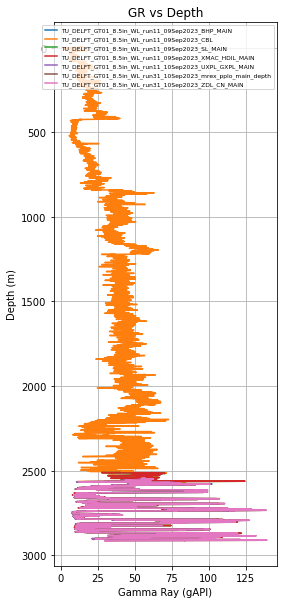

In [96]:
import lasio
import matplotlib.pyplot as plt
import glob

# ---------- GR vs Depth ----------
plt.figure(figsize=(4, 10))

for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "GR" in las.curves:
        plt.plot(las["GR"], las.index, label=f.split(".las")[0])

plt.gca().invert_yaxis()
plt.xlabel("Gamma Ray (gAPI)")
plt.ylabel("Depth (m)")
plt.title("GR vs Depth")
plt.legend(fontsize=6)
plt.grid(True)
plt.show()


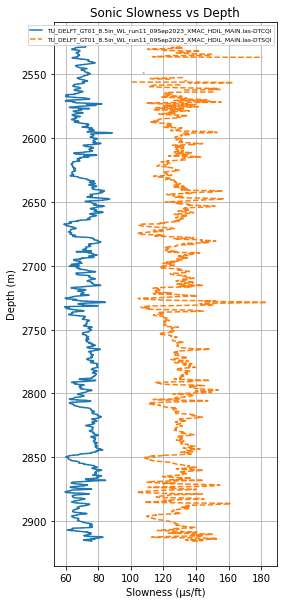

In [97]:
# ---------- DTCQI & DTSQI vs Depth ----------
plt.figure(figsize=(4, 10))

for f in glob.glob("*.las"):
    las = lasio.read(f)

    if "DTCQI" in las.curves:
        plt.plot(las["DTCQI"], las.index, label=f"{f}-DTCQI")

    if "DTSQI" in las.curves:
        plt.plot(las["DTSQI"], las.index, linestyle="--", label=f"{f}-DTSQI")

plt.gca().invert_yaxis()
plt.xlabel("Slowness (µs/ft)")
plt.ylabel("Depth (m)")
plt.title("Sonic Slowness vs Depth")
plt.legend(fontsize=6)
plt.grid(True)
plt.show()


# Compressional and shear velocities 

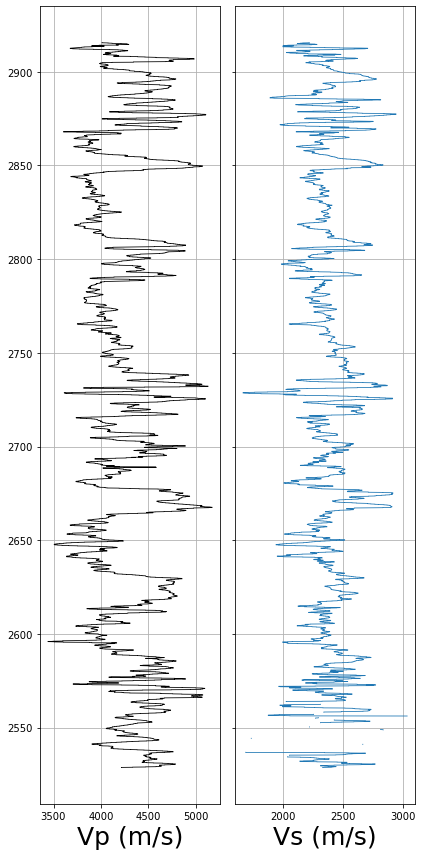

In [98]:
import lasio
import glob
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(6, 12), sharey=True)

# ---------- Vp ----------
for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "DTCQI" in las.curves:
        dtc = las["DTCQI"]          # µs/ft
        vp = 0.3048e6 / dtc         # m/s
        axes[0].plot(vp, las.index, lw=0.8, color='k')

axes[0].invert_yaxis()
axes[0].set_xlabel("Vp (m/s)", fontsize =25)
#axes[0].set_title("P-wave Velocity", fontsize =25)
axes[0].grid(True)

# ---------- Vs ----------
for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "DTSQI" in las.curves:
        dts = las["DTSQI"]          # µs/ft
        vs = 0.3048e6 / dts         # m/s
        axes[1].plot(vs, las.index, lw=0.8)

axes[1].invert_yaxis()
axes[1].set_xlabel("Vs (m/s)", fontsize =25)
#axes[1].set_title("S-wave Velocity", fontsize =25)
axes[1].grid(True)

plt.tight_layout()

plt.savefig('velocities.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [99]:
import lasio
import glob
import numpy as np

Vp_all = []
Vs_all = []

for f in glob.glob("*.las"):
    las = lasio.read(f)

    # P-wave velocity
    if "DTCQI" in las.curves:
        dtc = las["DTCQI"]
        vp = 0.3048e6 / dtc   # m/s
        vp = vp[np.isfinite(vp)]
        Vp_all.append(vp)

    # S-wave velocity
    if "DTSQI" in las.curves:
        dts = las["DTSQI"]
        vs = 0.3048e6 / dts   # m/s
        vs = vs[np.isfinite(vs)]
        Vs_all.append(vs)

# Merge all wells
Vp_all = np.concatenate(Vp_all)
Vs_all = np.concatenate(Vs_all)

# Print statistics
print("\n=== P-wave velocity (Vp) [m/s] ===")
print(f"Min : {Vp_all.min():.0f}")
print(f"Max : {Vp_all.max():.0f}")
print(f"Mean: {Vp_all.mean():.0f}")

print("\n=== S-wave velocity (Vs) [m/s] ===")
print(f"Min : {Vs_all.min():.0f}")
print(f"Max : {Vs_all.max():.0f}")
print(f"Mean: {Vs_all.mean():.0f}")



=== P-wave velocity (Vp) [m/s] ===
Min : 3441
Max : 5175
Mean: 4264

=== S-wave velocity (Vs) [m/s] ===
Min : 1663
Max : 3036
Mean: 2382


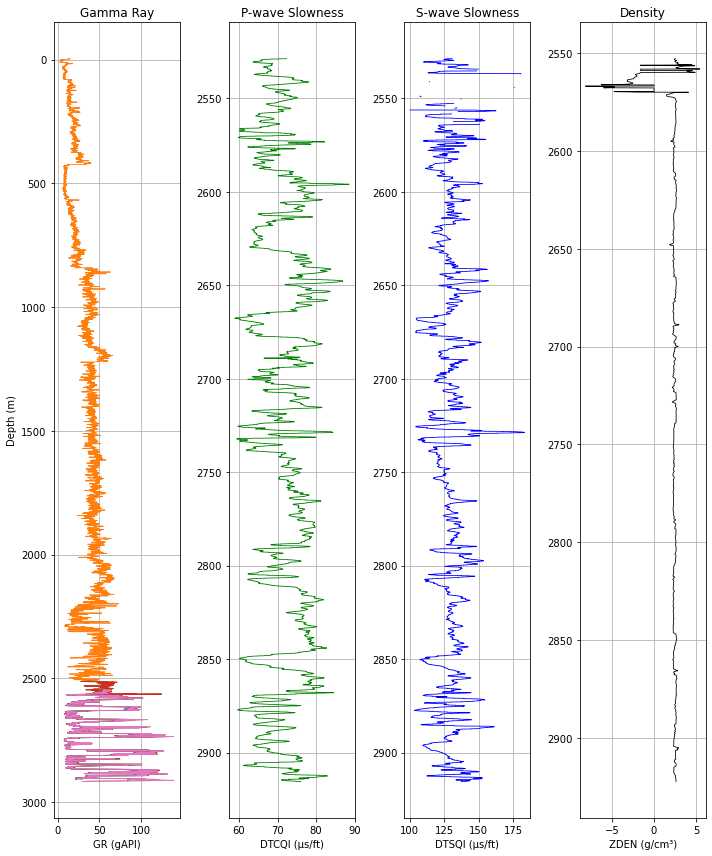

In [14]:
import lasio
import glob
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(10, 12), sharey=False)

# ---------- GR ----------
for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "GR" in las.curves:
        axes[0].plot(las["GR"], las.index, linewidth=0.8)

axes[0].invert_yaxis()
axes[0].set_xlabel("GR (gAPI)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Gamma Ray")
axes[0].grid(True)

# ---------- DTCQI ----------
for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "DTCQI" in las.curves:
        axes[1].plot(las["DTCQI"], las.index, color="green", linewidth=0.8)

axes[1].invert_yaxis()
axes[1].set_xlabel("DTCQI (µs/ft)")
axes[1].set_title("P-wave Slowness")
axes[1].grid(True)

# ---------- DTSQI ----------
for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "DTSQI" in las.curves:
        axes[2].plot(las["DTSQI"], las.index, color="blue", linewidth=0.8)

axes[2].invert_yaxis()
axes[2].set_xlabel("DTSQI (µs/ft)")
axes[2].set_title("S-wave Slowness")
axes[2].grid(True)

# ---------- ZDEN ----------
for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "ZDEN" in las.curves:
        axes[3].plot(las["ZDEN"], las.index, color="black", linewidth=0.8)

axes[3].invert_yaxis()
axes[3].set_xlabel("ZDEN (g/cm³)")
axes[3].set_title("Density")
axes[3].grid(True)

plt.tight_layout()
plt.show()


In [15]:
import lasio

las = lasio.read("DELGT01_formationtops.las")

print(las.sections.keys())


dict_keys(['Version', 'Well', 'Curves', 'Parameter', 'Other'])


In [100]:
formations = [
    ("NUMS–Massluis",        0,    100),
    ("NUOO–Oosterhout",    100,    250),
    ("NUBR–Breda",         250,    380),
    ("Ommelande",         380,    430),
    ("CKTX–Texel",         430,    520),
    ("KNGLU–Upper Holland Marl",  520,    590),
    ("GLM–Middle Holland Clast", 590,    790),
    ("GLG–Holland Greens.",790,   865),
    ("GLL–Lower Holland", 865,  975),
    ("KNNSL–De Lier Sst", 975,  1230),
    ("KNNCN–Vlieland Clay",1230,  1350),
    ("KNNCC–Berkel Clast.",1350,  2010),
    ("KNNSR–Rijswijk Sst", 2010,  2300),
    ("SLDNR–Rodenrijs Clst",2300, 2430),
    ("SLDND–Delft Sst",    2430,  2590),
    ("SLDNA–Alblsserdam",  2590,  2910),
]


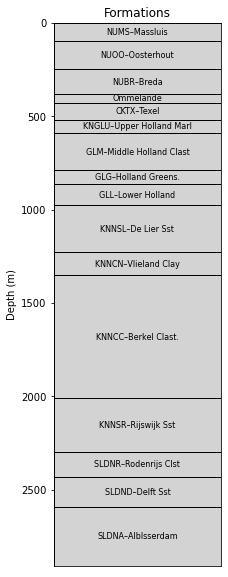

In [101]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 10))

for name, top, base in formations:
    ax.barh(
        y=(top + base) / 2,
        width=1,
        height=(base - top),
        color="lightgray",
        edgecolor="black"
    )
    ax.text(
        0.5, (top + base) / 2, name,
        ha="center", va="center", fontsize=8
    )

ax.set_ylim(2910, 0)   # invert depth
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_ylabel("Depth (m)")
ax.set_title("Formations")

plt.show()


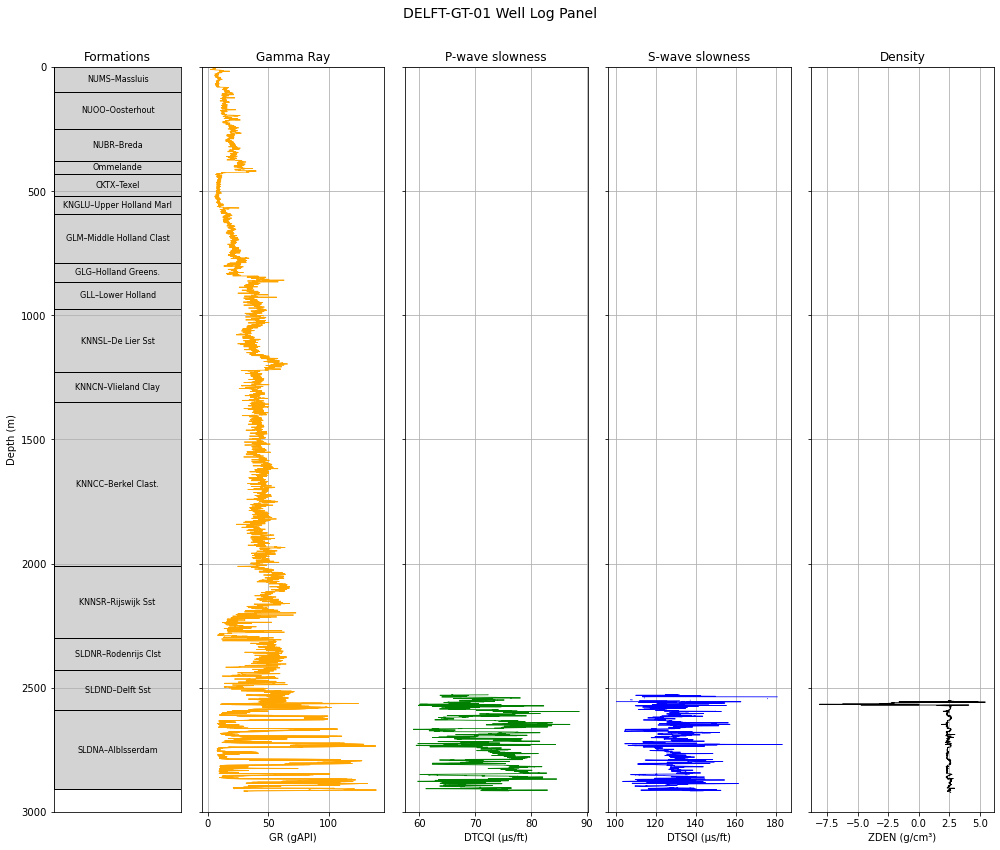

In [19]:
import matplotlib.pyplot as plt
import lasio
import glob

fig, axes = plt.subplots(
    1, 5,
    figsize=(14, 12),
    sharey=True,
    gridspec_kw={"width_ratios": [1.4, 2, 2, 2, 2]}
)

ax_form, ax_gr, ax_dt, ax_ds, ax_den = axes

for name, top, base in formations:
    ax_form.barh(
        y=(top + base) / 2,
        width=1,
        height=(base - top),
        color="lightgray",
        edgecolor="black"
    )
    ax_form.text(
        0.5, (top + base) / 2,
        name,
        ha="center", va="center",
        fontsize=8
    )

ax_form.set_xlim(0, 1)
ax_form.set_xticks([])
ax_form.set_ylabel("Depth (m)")
ax_form.set_title("Formations")

for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "GR" in las.curves:
        ax_gr.plot(las["GR"], las.index, color="orange", linewidth=0.8)

ax_gr.set_xlabel("GR (gAPI)")
ax_gr.set_title("Gamma Ray")


for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "DTCQI" in las.curves:
        ax_dt.plot(las["DTCQI"], las.index, color="green", linewidth=0.8)

ax_dt.set_xlabel("DTCQI (µs/ft)")
ax_dt.set_title("P-wave slowness")

for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "DTSQI" in las.curves:
        ax_ds.plot(las["DTSQI"], las.index, color="blue", linewidth=0.8)

ax_ds.set_xlabel("DTSQI (µs/ft)")
ax_ds.set_title("S-wave slowness")

for f in glob.glob("*.las"):
    las = lasio.read(f)
    if "ZDEN" in las.curves:
        ax_den.plot(las["ZDEN"], las.index, color="black", linewidth=0.8)

ax_den.set_xlabel("ZDEN (g/cm³)")
ax_den.set_title("Density")


for ax in axes:
    ax.invert_yaxis()
    ax.grid(True)

# optional: hard-set depth range
ax_form.set_ylim(3000, 0)

plt.suptitle("DELFT-GT-01 Well Log Panel", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



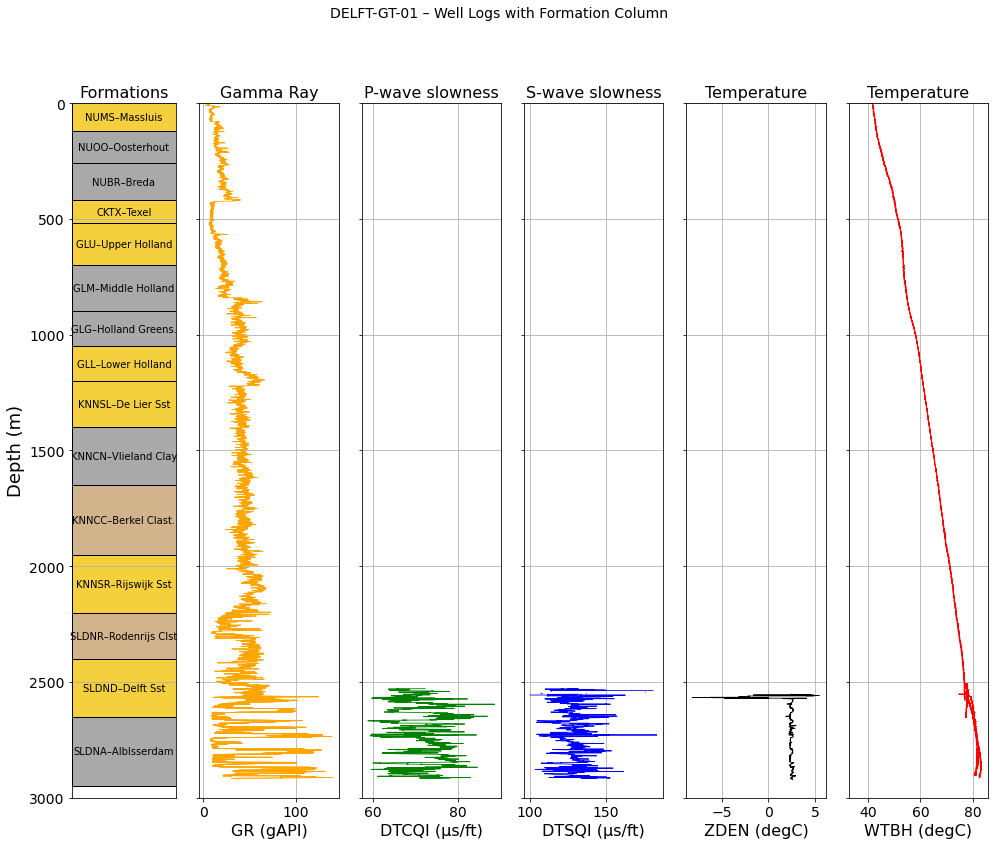

In [21]:
import matplotlib.pyplot as plt
import lasio
import glob

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})



# -------------------------------------------------
# 1) Define formations: (name, top, base, lithology)
# -------------------------------------------------
formations = [
    ("NUMS–Massluis",        0,    120,  "sand"),
    ("NUOO–Oosterhout",    120,    260,  "clay"),
    ("NUBR–Breda",         260,    420,  "clay"),
    ("CKTX–Texel",         420,    520,  "sand"),
    ("GLU–Upper Holland",  520,    700,  "sand"),
    ("GLM–Middle Holland", 700,    900,  "clay"),
    ("GLG–Holland Greens.",900,   1050,  "clay"),
    ("GLL–Lower Holland", 1050,  1200,  "sand"),
    ("KNNSL–De Lier Sst", 1200,  1400,  "sand"),
    ("KNNCN–Vlieland Clay",1400,  1650,  "clay"),
    ("KNNCC–Berkel Clast.",1650,  1950,  "mixed"),
    ("KNNSR–Rijswijk Sst", 1950,  2200,  "sand"),
    ("SLDNR–Rodenrijs Clst",2200, 2400,  "mixed"),
    ("SLDND–Delft Sst",    2400,  2650,  "sand"),
    ("SLDNA–Alblsserdam",  2650,  2950,  "clay"),
]

# Lithology colors
litho_colors = {
    "sand":  "#F4D03F",   # yellow
    "clay":  "#A9A9A9",   # grey
    "mixed": "#D2B48C"    # tan
}

# -------------------------------------------------
# 2) Create figure layout (formation + 4 logs)
# -------------------------------------------------
fig, axes = plt.subplots(
    1, 6,
    figsize=(14, 12),
    sharey=True,
    gridspec_kw={"width_ratios": [1.5, 2, 2, 2, 2,2]}
)

ax_form, ax_gr, ax_dt, ax_ds, ax_den, ax_temp = axes

# -------------------------------------------------
# 3) Formation column (colored)
# -------------------------------------------------
for name, top, base, lith in formations:
    ax_form.barh(
        y=(top + base) / 2,
        width=1,
        height=(base - top),
        color=litho_colors[lith],
        edgecolor="black"
    )
    ax_form.text(
        0.5, (top + base) / 2,
        name,
        ha="center", va="center",
        fontsize=10
    )

ax_form.set_xlim(0, 1)
ax_form.set_xticks([])
ax_form.set_ylabel("Depth (m)")
ax_form.set_title("Formations")

# -------------------------------------------------
# 4) Plot logs (each from its own LAS file)
# -------------------------------------------------
for f in glob.glob("*.las"):
    las = lasio.read(f)

    if "GR" in las.curves:
        ax_gr.plot(las["GR"], las.index, color="orange", linewidth=0.8)

    if "DTCQI" in las.curves:
        ax_dt.plot(las["DTCQI"], las.index, color="green", linewidth=0.8)

    if "DTSQI" in las.curves:
        ax_ds.plot(las["DTSQI"], las.index, color="blue", linewidth=0.8)

    if "ZDEN" in las.curves:
        ax_den.plot(las["ZDEN"], las.index, color="black", linewidth=0.8)

    if "WTBH" in las.curves:
        ax_temp.plot(las["WTBH"], las.index, color="red", linewidth=0.8)

ax_gr.set_xlabel("GR (gAPI)")
ax_gr.set_title("Gamma Ray")

ax_dt.set_xlabel("DTCQI (µs/ft)")
ax_dt.set_title("P-wave slowness")

ax_ds.set_xlabel("DTSQI (µs/ft)")
ax_ds.set_title("S-wave slowness")

ax_den.set_xlabel("ZDEN (g/cm³)")
ax_den.set_title("Density")

ax_temp.set_xlabel("WTBH (degC)")
ax_temp.set_title("Temperature")

# -------------------------------------------------
# 5) Common depth scale + styling
# -------------------------------------------------
for ax in axes:
    ax.invert_yaxis()
    ax.grid(True)

ax_form.set_ylim(3000, 0)

plt.suptitle("DELFT-GT-01 – Well Logs with Formation Column", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

#plt.suptitle(
    #"DELFT-GT-01 – Well Logs with Formation Column",
    #fontsize=20,
    #fontweight="bold"
#)

plt.tight_layout(rect=[0, 0, 1, 0.94])
ax_form.set_ylabel("Depth (m)", fontsize=18)
ax_form.set_title("Formations", fontsize=16)

ax_gr.set_xlabel("GR (gAPI)", fontsize=16)
ax_gr.set_title("Gamma Ray", fontsize=16)

ax_dt.set_xlabel("DTCQI (µs/ft)", fontsize=16)
ax_dt.set_title("P-wave slowness", fontsize=16)

ax_ds.set_xlabel("DTSQI (µs/ft)", fontsize=16)
ax_ds.set_title("S-wave slowness", fontsize=16)

ax_den.set_xlabel("ZDEN (degC)", fontsize=16)
ax_den.set_title("Temperature", fontsize=16)

ax_temp.set_xlabel("WTBH (degC)", fontsize=16)
ax_temp.set_title("Temperature", fontsize=16)

plt.savefig(
    "DELFT_GT_01_well_logs.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()


plt.show()



FILE: TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las
  Density (Gardner) statistics:
    min = 1.76 g/cm3
    max = 1.95 g/cm3
    mean = 1.86 g/cm3


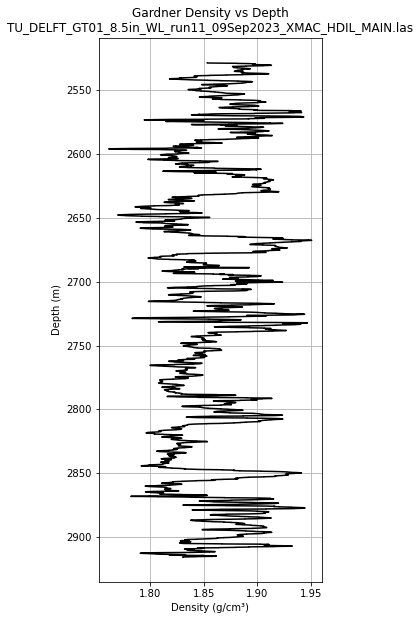

In [20]:
import lasio
import matplotlib.pyplot as plt
import glob
import numpy as np

# -------------------------------------------------
# Loop over LAS files and process those with DTCQI
# -------------------------------------------------
for f in glob.glob("*.las"):
    las = lasio.read(f)

    if "DTCQI" in las.curves:
        depth = las.index
        dtco = las["DTCQI"]  # µs/ft

        # ---- Convert slowness to Vp (m/s)
        vp = 304800.0 / dtco

        # ---- Gardner density (g/cm3)
        rho_gardner = 0.23 * np.power(vp, 0.25)

        # ---- Print summary
        print("\nFILE:", f)
        print("  Density (Gardner) statistics:")
        print(f"    min = {np.nanmin(rho_gardner):.2f} g/cm3")
        print(f"    max = {np.nanmax(rho_gardner):.2f} g/cm3")
        print(f"    mean = {np.nanmean(rho_gardner):.2f} g/cm3")

        # ---- Plot density vs depth
        plt.figure(figsize=(4, 10))
        plt.plot(rho_gardner, depth, color="black")
        plt.gca().invert_yaxis()
        plt.xlabel("Density (g/cm³)")
        plt.ylabel("Depth (m)")
        plt.title(f"Gardner Density vs Depth\n{f}")
        plt.grid(True)
        plt.show()



FILE: TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las
  Gardner density (g/cm3):
    min = 2.37, max = 2.63, mean = 2.50
  Belotti density (g/cm3):
    min = 2.50, max = 2.72, mean = 2.62


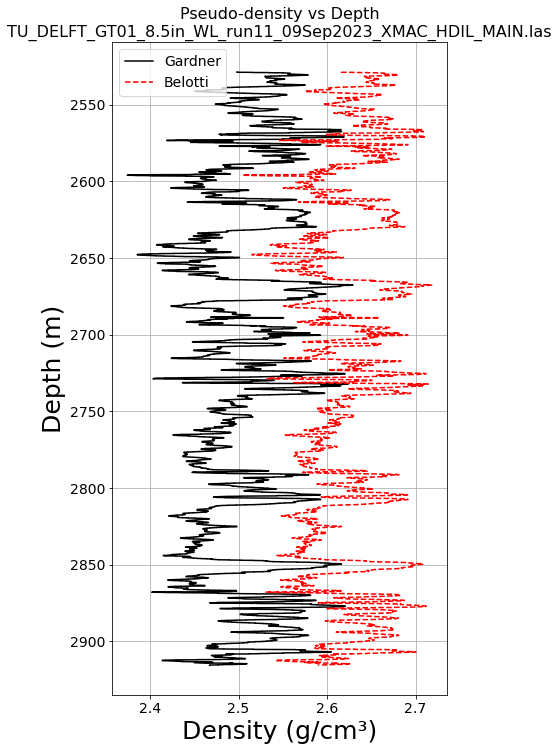

In [77]:
import lasio
import matplotlib.pyplot as plt
import glob
import numpy as np

# -----------------------------
# Set matrix slowness (µs/ft)
# CHANGE THIS if needed
DT_MATRIX = 55   # sandstone
# -----------------------------

for f in glob.glob("*.las"):
    las = lasio.read(f)

    if "DTCQI" in las.curves:
        depth = las.index
        dtco = las["DTCQI"]  # µs/ft

        # ---- Gardner method
        vp = 304800.0 / dtco  # m/s
        rho_gardner = 0.31 * np.power(vp, 0.25)

        # ---- Belotti method
        rho_belotti = 2.75 - (2.11 * (dtco - DT_MATRIX)) / (dtco + 200.0)

        # ---- Print statistics
        print("\nFILE:", f)
        print("  Gardner density (g/cm3):")
        print(f"    min = {np.nanmin(rho_gardner):.2f}, "
              f"max = {np.nanmax(rho_gardner):.2f}, "
              f"mean = {np.nanmean(rho_gardner):.2f}")

        print("  Belotti density (g/cm3):")
        print(f"    min = {np.nanmin(rho_belotti):.2f}, "
              f"max = {np.nanmax(rho_belotti):.2f}, "
              f"mean = {np.nanmean(rho_belotti):.2f}")

        # ---- Plot vs depth
        plt.figure(figsize=(6, 12))
        plt.plot(rho_gardner, depth, label="Gardner", color="black")
        plt.plot(rho_belotti, depth, label="Belotti", color="red", linestyle="--")
        plt.gca().invert_yaxis()
        plt.xlabel("Density (g/cm³)", fontsize=25)
        plt.ylabel("Depth (m)", fontsize=25)
        plt.title(f"Pseudo-density vs Depth\n{f}")
        plt.legend()
        plt.grid(True)
        plt.savefig('Densities.png', dpi=300, bbox_inches='tight', transparent=True)

        
        plt.show()


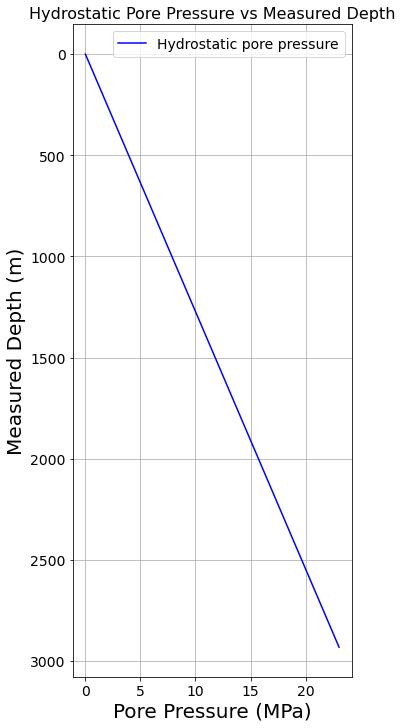

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Depth definitions
# -------------------------------------------------
TVD_max = 2348   # True Vertical Depth (m)
MD_max = 2931    # Measured Depth (m)

# Create depth arrays
TVD = np.linspace(0, TVD_max, 500)
MD = np.linspace(0, MD_max, 500)

# -------------------------------------------------
# Hydrostatic pore pressure
# -------------------------------------------------
rho_f = 1000.0   # kg/m3 (water)
g = 9.81         # m/s2

Pp = rho_f * g * TVD / 1e6   # MPa

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 12))

ax.plot(Pp, MD, color="blue", lw=1.5, label="Hydrostatic pore pressure")

ax.invert_yaxis()
ax.set_xlabel("Pore Pressure (MPa)", fontsize=20)
ax.set_ylabel("Measured Depth (m)", fontsize=20)
ax.set_title("Hydrostatic Pore Pressure vs Measured Depth")
ax.grid(True)
ax.legend()

plt.show()


Survey loaded ✔  TD TVD = 2348.95


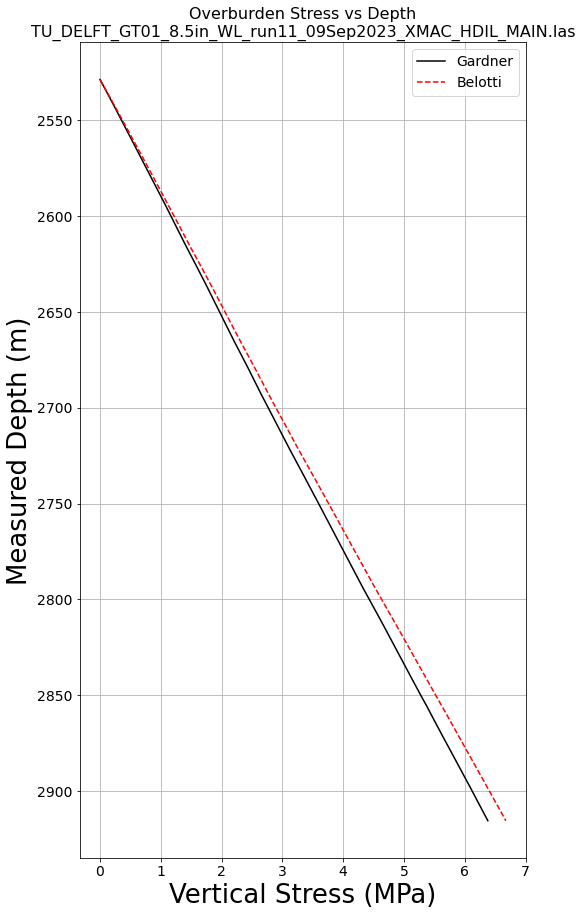

In [81]:
import lasio
import matplotlib.pyplot as plt
import glob
import numpy as np
import pandas as pd

# -----------------------------
# Load deviation survey
# -----------------------------
survey_file = "20230908_1225in_DEL-GT-01_Surveys_2931m TD.xlsx"

df = pd.read_excel(survey_file, header=19)
df.columns = df.columns.str.strip()

df["MD"] = pd.to_numeric(df["MD"], errors="coerce")
df["TVD"] = pd.to_numeric(df["TVD"], errors="coerce")

df = df.dropna(subset=["MD", "TVD"])

MD_dev = df["MD"].values
TVD_dev = df["TVD"].values

print("Survey loaded ✔  TD TVD =", TVD_dev[-1])

# -----------------------------
# Constants
# -----------------------------
DT_MATRIX = 55
G = 9.81
GCMS3_TO_KGM3 = 1000
PA_TO_MPA = 1e-6

# -----------------------------
# Loop LAS files (your method)
# -----------------------------
for f in glob.glob("*.las"):
    las = lasio.read(f)

    if "DTCQI" in las.curves:

        depth = np.asarray(las.index)
        dtco = np.asarray(las["DTCQI"])

        mask = np.isfinite(depth) & np.isfinite(dtco)
        depth = depth[mask]
        dtco = dtco[mask]

        # -----------------------------
        # Interpolate TVD
        # -----------------------------
        TVD_interp = np.interp(depth, MD_dev, TVD_dev)
        dz = np.gradient(TVD_interp)

        # -----------------------------
        # Density estimation
        # -----------------------------
        vp = 304800.0 / dtco

        rho_gardner = 0.31 * np.power(vp, 0.25)
        rho_belotti = 2.75 - (2.11 * (dtco - DT_MATRIX)) / (dtco + 200.0)

        rho_gardner_si = rho_gardner * GCMS3_TO_KGM3
        rho_belotti_si = rho_belotti * GCMS3_TO_KGM3

        # -----------------------------
        # Stress calculation
        # -----------------------------
        sigma_v_gardner = np.cumsum(rho_gardner_si * G * dz) * PA_TO_MPA
        sigma_v_belotti = np.cumsum(rho_belotti_si * G * dz) * PA_TO_MPA

        # -----------------------------
        # Plot
        # -----------------------------
        plt.figure(figsize=(8, 15))

        plt.plot(sigma_v_gardner, depth, label="Gardner", color="black")
        plt.plot(sigma_v_belotti, depth, label="Belotti", color="red", linestyle="--")

        plt.gca().invert_yaxis()
        plt.xlabel("Vertical Stress (MPa)", fontsize=26)
        plt.ylabel("Measured Depth (m)", fontsize=26)
        plt.title(f"Overburden Stress vs Depth\n{f}")
        plt.legend()
        plt.grid(True)

        plt.savefig('OverburdenStress.png', dpi=300, bbox_inches='tight', transparent=True)
        plt.show()


2.34590909


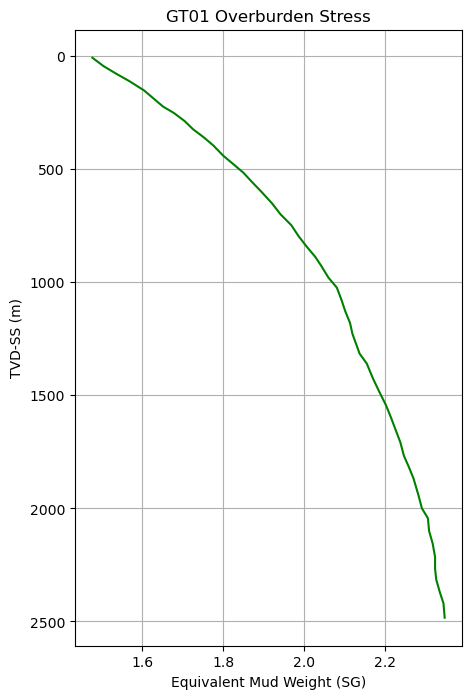

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Overburden.csv")

x = df["Overburden stress (SG)"].to_numpy()
y = df["Depth (m)"].to_numpy()

plt.figure(figsize=(5, 8))
plt.plot(x, y, color="green")
plt.gca().invert_yaxis()

plt.xlabel("Equivalent Mud Weight (SG)")
plt.ylabel("TVD-SS (m)")
plt.title("GT01 Overburden Stress")
plt.grid(True)
print(np.max(x))
plt.show()


Max stress (MPa) = 57.15621040874449
53


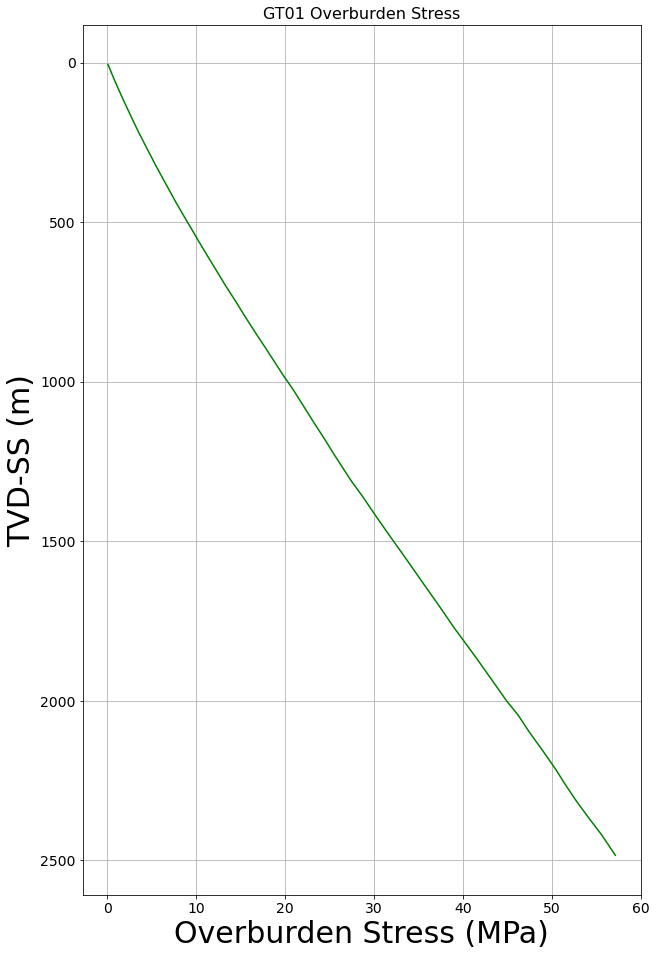

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Overburden.csv")

SG = df["Overburden stress (SG)"].to_numpy()
depth = df["Depth (m)"].to_numpy()

# Convert to MPa
pressure_mpa = SG * 0.00981 * depth

plt.figure(figsize=(10, 16))
plt.plot(pressure_mpa, depth, color="green")
plt.gca().invert_yaxis()

plt.xlabel("Overburden Stress (MPa)", fontsize=30)
plt.ylabel("TVD-SS (m)", fontsize=30)
plt.title("GT01 Overburden Stress")
plt.grid(True)

print("Max stress (MPa) =", np.max(pressure_mpa))

print(len(SG))

plt.savefig('OverburdenStress.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [119]:
SG = 2.35
TVD = 2550  # m

Sv = 0.00981 * SG * TVD
print(Sv, "MPa")


58.786424999999994 MPa


In [120]:
import numpy as np
import matplotlib.pyplot as plt

# Select interval
mask = (depth >= 2550) & (depth <= 2930)
z = depth[mask]
rho = rho_belotti[mask]

# Vertical stress (MPa)
Sv = np.zeros_like(z)
Sv[0] = 59.0   # MPa at 2550 m (given reference)

for i in range(1, len(z)):
    dz = z[i] - z[i-1]
    Sv[i] = Sv[i-1] + 0.00981 * rho[i] * dz


IndexError: boolean index did not match indexed array along dimension 0; dimension is 5603 but corresponding boolean dimension is 53

In [42]:
SG = Sv / (0.00981 * z)
print(z)

[2550.033  2550.1092 2550.1854 ... 2915.412  2915.4882 2915.5644]


ValueError: x and y must have same first dimension, but have shapes (1,) and (4798,)

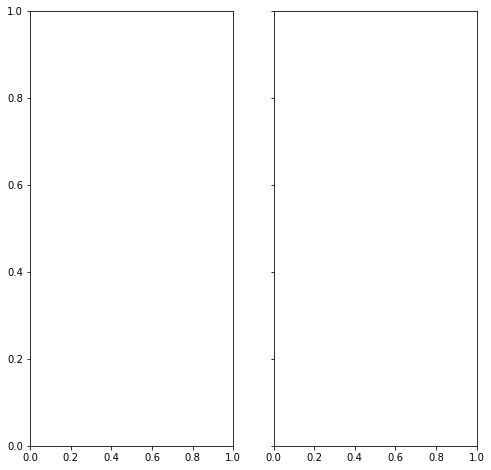

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

# ---- Vertical stress (MPa)
axes[0].plot(Sv, z, color="black")
axes[0].invert_yaxis()
axes[0].set_xlabel("Vertical Stress Sv (MPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Sv from Density")
axes[0].grid(True)

# ---- Equivalent Mud Weight (SG)
axes[1].plot(SG, z, color="red")
axes[1].set_xlabel("Equivalent Mud Weight (SG)")
axes[1].set_title("Sv expressed as SG")
axes[1].grid(True)

plt.tight_layout()
plt.show()


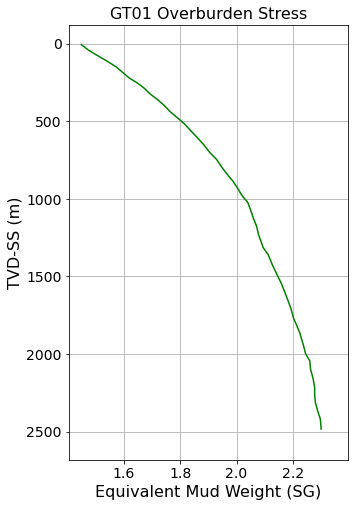

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Overburden.csv")

x = df["Overburden stress (SG)"].to_numpy()
y = df["Depth (m)"].to_numpy()

plt.figure(figsize=(5, 8))
plt.plot(x, y, color="green")
plt.plot(SG, z, color="red")
plt.gca().invert_yaxis()

plt.xlabel("Equivalent Mud Weight (SG)")
plt.ylabel("TVD-SS (m)")
plt.title("GT01 Overburden Stress")
plt.grid(True)
plt.show()


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data
df = pd.read_csv("Overburden.csv")

TVD_import = df["Depth (m)"].to_numpy()
sg = df["Overburden stress (SG)"].to_numpy()

print(len(sg))

# Convert SG → MPa
overburden_mpa = sg * 9.81 * depth_shallow / 1000.0

# Plot
plt.figure(figsize=(5, 8))
plt.plot(overburden_mpa, depth_shallow, color="green", linewidth=2)
plt.gca().invert_yaxis()

plt.xlabel("Overburden Stress (MPa)")
plt.ylabel("TVD-SS (m)")
plt.title("GT01 Overburden Stress (Surface–2530 m)")
plt.grid(True)

print(len(depth_shallow))
plt.show()


53


ValueError: operands could not be broadcast together with shapes (53,) (54,) 

58.988518819558436


ValueError: x and y must have same first dimension, but have shapes (5132,) and (108,)

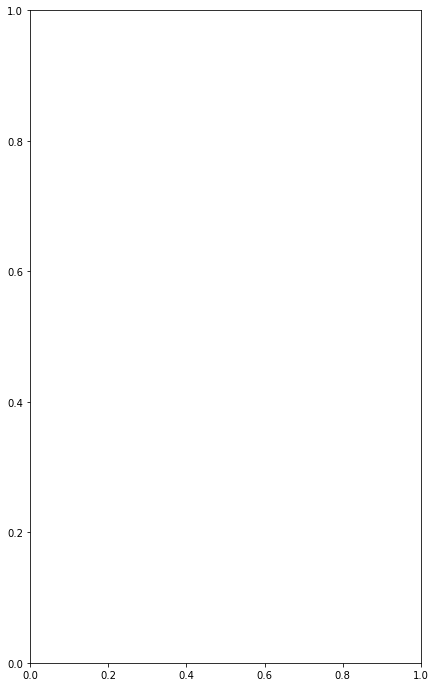

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Shift deep stress so it continues from shallow
sigma_v_belotti_corr = sigma_v_belotti + 58.2

# 2) Merge vectors (NO renaming)
depth_merged = np.concatenate([depth_shallow, depth])
stress_merged = np.concatenate([overburden_mpa, sigma_v_belotti_corr])

print( overburden_mpa[53])

# 3) Plot merged curve
plt.figure(figsize=(7, 12))
plt.plot(stress_merged, depth_merged, color="black", linewidth=2)

plt.gca().invert_yaxis()
plt.xlabel("Overburden Stress σᵥ (MPa)", fontsize= 28)
plt.ylabel("Depth (m)", fontsize= 28)
plt.title("GT01 Total Overburden Stress (0–2930 m)", fontsize= 18)

plt.xticks(fontsize=20)  # Change the font size for x-axis ticks
plt.yticks(fontsize=20)  # Change the font size for y-axis ticks
plt.grid(True)

plt.savefig("OverburdenStress_total.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()



In [48]:
pip install lasio numpy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [30]:
def slowness_to_velocity(slowness_us_ft):
    """
    Convert slowness [µs/ft] to velocity [km/s]
    """
    return 0.3048 / slowness_us_ft * 1e6 / 1000


In [31]:
def poisson_ratio_dynamic(Vp, Vs):
    return (Vp**2 - 2*Vs**2) / (2*(Vp**2 - Vs**2))


def youngs_modulus_dynamic(Vp, Vs, rho):
    """
    rho in kg/m3
    E in GPa
    """
    E = rho * (Vs**2) * (3*Vp**2 - 4*Vs**2) / (Vp**2 - Vs**2)
    return E / 1e9


def friction_lal_vp(Vp):
    return np.tan(np.arcsin((Vp - 1.0) / (Vp + 1.0)))


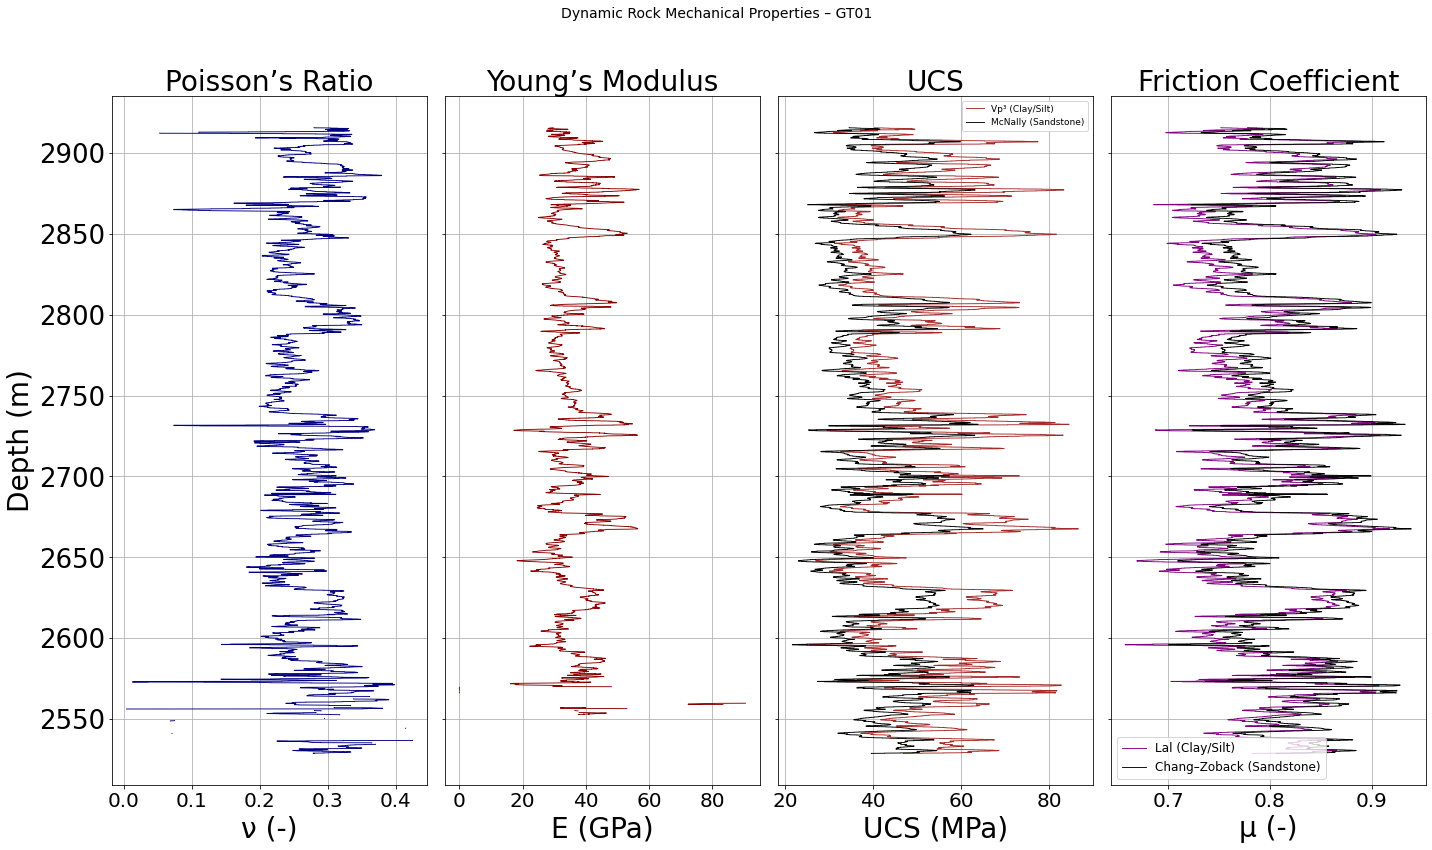

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import lasio

# =====================================================
# READ DATA
# =====================================================

# --- Sonic file ---
las_s = lasio.read("TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las")
depth = las_s.index

DTCO = las_s["DTCQI"]   # µs/ft
DTS  = las_s["DTSQI"]   # µs/ft

# velocities
Vp_km = (0.3048 / DTCO) * 1e6 / 1000   # km/s
Vs_km = (0.3048 / DTS)  * 1e6 / 1000   # km/s

Vp = Vp_km * 1000   # m/s
Vs = Vs_km * 1000   # m/s


# --- Density file ---
las_d = lasio.read("TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_ZDL_CN_MAIN.las")
depth_den = las_d.index
rho = las_d["ZDEN"] * 1000.0  # g/cm³ → kg/m³

# interpolate velocities onto density depth grid
Vp_i = np.interp(depth_den, depth, Vp)
Vs_i = np.interp(depth_den, depth, Vs)


# =====================================================
# CALCULATIONS
# =====================================================

# --- Poisson’s ratio ---
nu = (Vp_km**2 - 2 * Vs_km**2) / (2 * (Vp_km**2 - Vs_km**2))
nu[(nu < 0) | (nu > 0.5)] = np.nan

# --- Young’s modulus (dynamic, GPa) ---
E = rho * (Vs_i**2) * (3 * Vp_i**2 - 4 * Vs_i**2) / (Vp_i**2 - Vs_i**2)
E = E / 1e9
E[E < 0] = np.nan

# --- UCS ---
# Vp³ (clay/silt)
UCS_vp3 = 1.25 * 72.5 * (Vp_km**3) / 1000.0 * 6.89476   # MPa

# McNally (sandstone)
UCS_mcnally = 0.45 * 185165 * np.exp(-0.037 * DTCO) / 1000.0 * 6.89476  # MPa

# --- Friction ---
mu_lal = np.tan(np.arcsin((Vp_km - 1) / (Vp_km + 1)))
mu_cz  = np.tan((18.532 * (Vp_km**0.5148)) * np.pi / 180)

# clean
for arr in [UCS_vp3, UCS_mcnally, mu_lal, mu_cz]:
    arr[~np.isfinite(arr)] = np.nan


# =====================================================
# PLOTTING
# =====================================================




fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 12),
    sharey=True
)

ax_nu, ax_E, ax_ucs, ax_mu = axes

# --- Poisson ---
ax_nu.plot(nu, depth, color="navy", lw=0.9)
ax_nu.set_xlabel("ν (-)", fontsize = 28)
ax_nu.set_title("Poisson’s Ratio", fontsize = 28)

# --- Young’s modulus ---
ax_E.plot(E, depth_den, color="darkred", lw=0.9)
ax_E.set_xlabel("E (GPa)", fontsize = 28)
ax_E.set_title("Young’s Modulus", fontsize = 28)

# --- UCS ---
ax_ucs.plot(UCS_vp3, depth, color="brown", lw=0.9, label="Vp³ (Clay/Silt)")
ax_ucs.plot(UCS_mcnally, depth, color="black", lw=0.9, label="McNally (Sandstone)")
ax_ucs.set_xlabel("UCS (MPa)", fontsize = 28)
ax_ucs.set_title("UCS", fontsize = 28)
ax_ucs.legend(fontsize=9)

# --- Friction ---
ax_mu.plot(mu_lal, depth, color="purple", lw=0.9, label="Lal (Clay/Silt)")
ax_mu.plot(mu_cz, depth, color="black", lw=0.9, label="Chang–Zoback (Sandstone)")
ax_mu.set_xlabel("μ (-)", fontsize = 28)
ax_mu.set_title("Friction Coefficient", fontsize = 28)
ax_mu.legend(fontsize=12)

# --- Common formatting ---
for ax in axes:
    ax.invert_yaxis()
    ax.grid(True)
    
for ax in axes:
    ax.invert_yaxis()
    ax.grid(True)
    ax.tick_params(axis="x", labelsize=20)


axes[0].set_ylabel("Depth (m)", fontsize = 28)
axes[0].tick_params(axis="y", labelsize=26) # Change the font size for y-axis ticks

plt.suptitle("Dynamic Rock Mechanical Properties – GT01", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("elastic_paramaters.png", dpi=300, bbox_inches="tight", transparent=True)


plt.show()


In [34]:
import lasio
import pandas as pd
import numpy as np

# --- read sonic ---
las_sonic = lasio.read("TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las")
df_sonic = pd.DataFrame({
    "depth": las_sonic.index,
    "DTCO": las_sonic["DTCQI"],
    "DTS":  las_sonic["DTSQI"]
})

# --- read density ---
las_den = lasio.read("TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_ZDL_CN_MAIN.las")
df_den = pd.DataFrame({
    "depth": las_den.index,
    "ZDEN": las_den["ZDEN"]
})

# --- merge by depth ---
df = pd.merge_asof(
    df_sonic.sort_values("depth"),
    df_den.sort_values("depth"),
    on="depth",
    direction="nearest",
    tolerance=0.15   # meters, adjust if needed
)

df.dropna(inplace=True)
print(df.shape)
print(df.columns)
df.head()

(4707, 4)
Index(['depth', 'DTCO', 'DTS', 'ZDEN'], dtype='object')


,depth,DTCO,DTS,ZDEN
598,2552.7762,67.4685,127.1832,2.5226
599,2552.8524,67.4685,127.1832,2.5050
600,2552.9286,67.1205,122.4400,2.4827
601,2553.0048,67.1205,122.4400,2.4583
602,2553.0810,67.2199,117.6940,2.4342


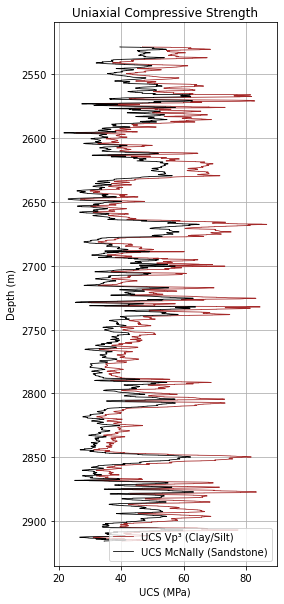

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import lasio

# ---- read sonic file ----
las = lasio.read("TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las")

depth = las.index
DTCO  = las["DTCQI"]

# ---- velocity (km/s) ----
Vp = (0.3048 / DTCO) * 1e6 / 1000

# ---- UCS methods ----
# 1) Vp³ method (Claystone / Siltstone)
UCS_vp3_ksi = 1.25 * 72.5 * (Vp**3) / 1000.0

# 2) Modified McNally (Sandstone)
UCS_mcnally_ksi = 0.45 * 185165 * np.exp(-0.037 * DTCO) / 1000.0

# ---- convert ksi → MPa ----
UCS_vp3 = UCS_vp3_ksi * 6.89476
UCS_mcnally = UCS_mcnally_ksi * 6.89476

# ---- clean ----
UCS_vp3[~np.isfinite(UCS_vp3)] = np.nan
UCS_mcnally[~np.isfinite(UCS_mcnally)] = np.nan

# ---- plot ----
fig, ax = plt.subplots(figsize=(4, 10))

ax.plot(UCS_vp3, depth, color="brown", lw=0.8,
        label="UCS Vp³ (Clay/Silt)")
ax.plot(UCS_mcnally, depth, color="black", lw=0.8,
        label="UCS McNally (Sandstone)")

ax.invert_yaxis()
ax.set_xlabel("UCS (MPa)")
ax.set_ylabel("Depth (m)")
ax.set_title("Uniaxial Compressive Strength")
ax.legend()
ax.grid(True)

plt.show()


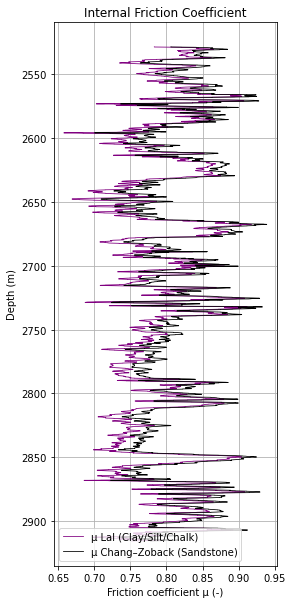

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import lasio

# ---- read sonic file ----
las = lasio.read("TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las")

depth = las.index
DTCO  = las["DTCQI"]

# ---- velocity (km/s) ----
Vp = (0.3048 / DTCO) * 1e6 / 1000

# -------------------------------------------------
# Internal Friction Coefficient
# -------------------------------------------------

# 1) Lal (Vp) – claystone / siltstone / chalk / marl
mu_lal = np.tan(np.arcsin((Vp - 1.0) / (Vp + 1.0)))

# 2) Chang–Zoback – sandstone
mu_cz = np.tan((18.532 * (Vp**0.5148)) * np.pi / 180.0)

# ---- clean ----
mu_lal[~np.isfinite(mu_lal)] = np.nan
mu_cz[~np.isfinite(mu_cz)] = np.nan

# ---- plot ----
fig, ax = plt.subplots(figsize=(4, 10))

ax.plot(mu_lal, depth, color="purple", lw=0.8,
        label="μ Lal (Clay/Silt/Chalk)")
ax.plot(mu_cz, depth, color="black", lw=0.8,
        label="μ Chang–Zoback (Sandstone)")

ax.invert_yaxis()
ax.set_xlabel("Friction coefficient μ (-)")
ax.set_ylabel("Depth (m)")
ax.set_title("Internal Friction Coefficient")
ax.legend()
ax.grid(True)

plt.show()


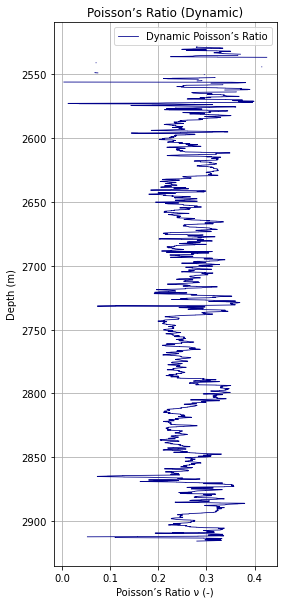

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import lasio

# ---- read sonic file ----
las = lasio.read("TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las")

depth = las.index
DTCO  = las["DTCQI"]   # µs/ft
DTS   = las["DTSQI"]   # µs/ft

# ---- velocities (km/s) ----
Vp = (0.3048 / DTCO) * 1e6 / 1000
Vs = (0.3048 / DTS)  * 1e6 / 1000

# -------------------------------------------------
# Poisson's Ratio (dynamic)
# -------------------------------------------------
nu = (Vp**2 - 2.0 * Vs**2) / (2.0 * (Vp**2 - Vs**2))

# ---- clean (physical bounds) ----
nu[~np.isfinite(nu)] = np.nan
nu[(nu < 0.0) | (nu > 0.5)] = np.nan

# ---- plot ----
fig, ax = plt.subplots(figsize=(4, 10))

ax.plot(nu, depth, color="darkblue", lw=0.8, label="Dynamic Poisson’s Ratio")

ax.invert_yaxis()
ax.set_xlabel("Poisson’s Ratio ν (-)")
ax.set_ylabel("Depth (m)")
ax.set_title("Poisson’s Ratio (Dynamic)")
ax.legend()
ax.grid(True)

plt.show()


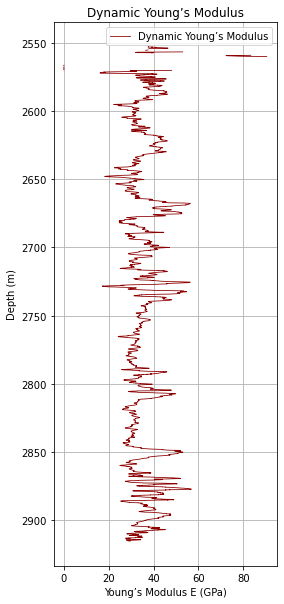

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import lasio

# -------------------------------------------------
# Read SONIC file
# -------------------------------------------------
las_s = lasio.read("TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las")

depth = las_s.index
DTCO  = las_s["DTCQI"]   # µs/ft
DTS   = las_s["DTSQI"]   # µs/ft

# velocities (m/s)
Vp = (0.3048 / DTCO) * 1e6
Vs = (0.3048 / DTS)  * 1e6


# -------------------------------------------------
# Read DENSITY file
# -------------------------------------------------
las_d = lasio.read("TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_ZDL_CN_MAIN.las")

rho = las_d["ZDEN"] * 1000.0   # g/cm³ → kg/m³
depth_den = las_d.index

# interpolate velocities onto density depth grid
Vp_i = np.interp(depth_den, depth, Vp)
Vs_i = np.interp(depth_den, depth, Vs)


# -------------------------------------------------
# Dynamic Young’s Modulus
# -------------------------------------------------
E = rho * (Vs_i**2) * (3.0 * Vp_i**2 - 4.0 * Vs_i**2) / (Vp_i**2 - Vs_i**2)

# Pa → GPa
E = E / 1e9


# ---- clean ----
E[~np.isfinite(E)] = np.nan
E[E < 0] = np.nan


# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 10))

ax.plot(E, depth_den, color="darkred", lw=0.8,
        label="Dynamic Young’s Modulus")

ax.invert_yaxis()
ax.set_xlabel("Young’s Modulus E (GPa)")
ax.set_ylabel("Depth (m)")
ax.set_title("Dynamic Young’s Modulus")
ax.legend()
ax.grid(True)

plt.show()


In [100]:
import numpy as np

# =====================================================
# MEAN VALUES (NaN-safe)
# =====================================================

results = {
    "Poisson_ratio_mean": np.nanmean(nu),
    "Youngs_modulus_mean_GPa": np.nanmean(E),

    "UCS_Vp3_mean_MPa": np.nanmean(UCS_vp3),
    "UCS_McNally_mean_MPa": np.nanmean(UCS_mcnally),

    "Friction_Lal_mean": np.nanmean(mu_lal),
    "Friction_ChangZoback_mean": np.nanmean(mu_cz),
}

# Pretty print
print("\n=== Average Dynamic Rock Mechanical Properties ===")
for k, v in results.items():
    print(f"{k:30s}: {v:.3f}")



=== Average Dynamic Rock Mechanical Properties ===
Poisson_ratio_mean            : 0.267
Youngs_modulus_mean_GPa       : 35.025
UCS_Vp3_mean_MPa              : 49.406
UCS_McNally_mean_MPa          : 41.024
Friction_Lal_mean             : 0.789
Friction_ChangZoback_mean     : 0.813


In [121]:
print(TVD_import)
print(len(TVD_import))

[   6.27272727   42.31363636   74.35909091  110.4136364   150.4681818
  186.5045455   222.5409091   250.5818182   286.6227273   322.6545455
  358.6954545   394.7318182   438.7681818   478.8090909   514.8454545
  554.8772727   598.9136364   650.9545455   698.9863636   747.0272727
  795.0545455   843.0863636   887.1181818   927.1409091   979.1681818
 1023.2        1079.218182   1127.231818   1179.25       1227.259091
 1271.272727   1315.286364   1359.313636   1423.336364   1479.359091
 1543.386364   1595.404545   1651.422727   1707.440909   1767.454545
 1815.472727   1867.490909   1939.509091   1999.522727   2043.545455
 2099.55       2155.563636   2215.572727   2267.572727   2315.577273
 2371.590909   2419.604545   2483.609091  ]
53


In [124]:
print(len(overburden_mpa))

54


[ 0.09090465  0.62424894  1.11856471  1.69932684  2.36812262  2.97852125
  3.60563158  4.12531936  4.79342703  5.46147963  6.16510176  6.87600668
  7.7448338   8.57650896  9.34137699 10.18029423 11.12709803 12.26376172
 13.31048119 14.42016965 15.48552313 16.59210633 17.63864743 18.56878446
 19.78106883 20.87819136 22.1463518  23.22964231 24.43833478 25.50439915
 26.52961269 27.5624804  28.72148464 30.28051715 31.68675211 33.32656975
 34.63477143 36.04233479 37.46288727 38.93332805 40.20154749 41.5699402
 43.39790881 44.91462008 46.19963964 47.52662104 48.98200908 50.47406
 51.65869777 52.81942803 54.30334116 55.61312022 57.15621041]
[ 0.09090465  0.62424894  1.11856471  1.69932684  2.36812262  2.97852125
  3.60563158  4.12531936  4.79342703  5.46147963  6.16510176  6.87600668
  7.7448338   8.57650896  9.34137699 10.18029423 11.12709803 12.26376172
 13.31048119 14.42016965 15.48552313 16.59210633 17.63864743 18.56878446
 19.78106883 20.87819136 22.1463518  23.22964231 24.43833478 25.50

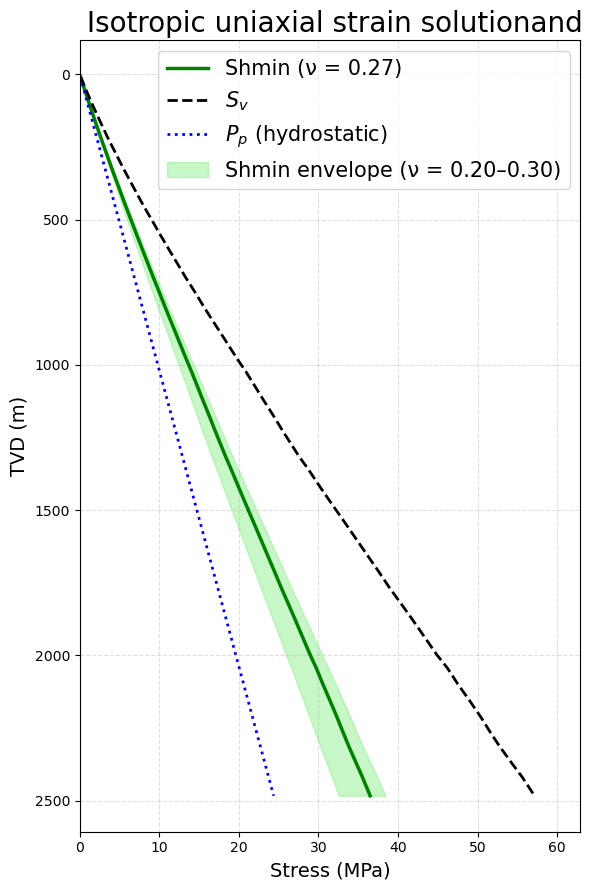

In [163]:
# =============================
# PARAMETERS
# =============================

alpha = 1.0
nu_avg = 0.27
nu_vals = np.linspace(0.20, 0.30, 50)

# Hydrostatic pore pressure
Pp = 0.00981 * depth
Sv = pressure_mpa
# Average Shmin
Sh_avg = (nu_avg / (1 - nu_avg)) * (Sv - alpha * Pp) + alpha * Pp

# Envelope
Sh_low = (nu_vals.min() / (1 - nu_vals.min())) * (Sv - Pp) + Pp
Sh_high = (nu_vals.max() / (1 - nu_vals.max())) * (Sv - Pp) + Pp

# =============================
# PLOT STYLE
# =============================

plt.style.use("default")


fig, ax = plt.subplots(figsize=(6, 9))

# Envelope
ax.fill_betweenx(depth, Sh_low, Sh_high,
                 color="lightgreen", alpha=0.5,
                 label="Shmin envelope (ν = 0.20–0.30)")

# Lines
ax.plot(Sh_avg, depth, color="green", linewidth=2.5,
        label="Shmin (ν = 0.27)")

ax.plot(Sv, depth, color="black", linestyle="--", linewidth=2,
        label="$S_v$")

ax.plot(Pp, depth, color="blue", linestyle=":", linewidth=2,
        label="$P_p$ (hydrostatic)")

# Axis formatting
ax.invert_yaxis()
ax.set_xlim(0, np.max(Sv)*1.1)

ax.set_xlabel("Stress (MPa)", fontsize=14)
ax.set_ylabel("TVD (m)", fontsize=14)
ax.set_title("Stress Profile", fontsize=16, pad=10)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# Legend
ax.legend(loc="upper right", frameon=True, fontsize = 15)
ax.set_title(" Isotropic uniaxial strain solutionand", fontsize = 20)

plt.tight_layout()
print(Sv)
print(pressure_mpa)
print(len(pressure_mpa))

plt.savefig("Shmin_USBnew.png", dpi=300, bbox_inches="tight", transparent=True)


plt.show()


30.93835268900983


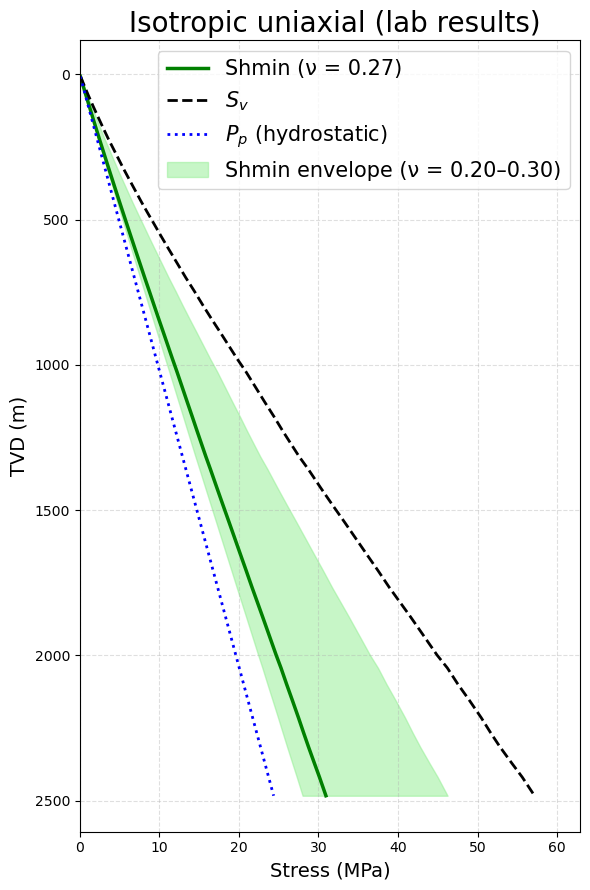

In [164]:
# =============================
# PARAMETERS
# =============================

alpha = 1.0
nu_avg = 0.167
nu_vals = np.linspace(0.1, 0.40, 50)

# Hydrostatic pore pressure
Pp = 0.00981 * depth

# Average Shmin
Sh_avg = (nu_avg / (1 - nu_avg)) * (Sv - alpha * Pp) + alpha * Pp

# Envelope
Sh_low = (nu_vals.min() / (1 - nu_vals.min())) * (Sv - Pp) + Pp
Sh_high = (nu_vals.max() / (1 - nu_vals.max())) * (Sv - Pp) + Pp

# =============================
# PLOT STYLE
# =============================

plt.style.use("default")


fig, ax = plt.subplots(figsize=(6, 9))

# Envelope
ax.fill_betweenx(depth, Sh_low, Sh_high,
                 color="lightgreen", alpha=0.5,
                 label="Shmin envelope (ν = 0.20–0.30)")

# Lines
ax.plot(Sh_avg, depth, color="green", linewidth=2.5,
        label="Shmin (ν = 0.27)")

ax.plot(Sv, depth, color="black", linestyle="--", linewidth=2,
        label="$S_v$")

ax.plot(Pp, depth, color="blue", linestyle=":", linewidth=2,
        label="$P_p$ (hydrostatic)")

# Axis formatting
ax.invert_yaxis()
ax.set_xlim(0, np.max(Sv)*1.1)

ax.set_xlabel("Stress (MPa)", fontsize=14)
ax.set_ylabel("TVD (m)", fontsize=14)
ax.set_title("Stress Profile", fontsize=16, pad=10)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# Legend
ax.legend(loc="upper right", frameon=True, fontsize = 15)
ax.set_title(" Isotropic uniaxial (lab results)", fontsize = 20)

plt.tight_layout()

print(np.max(Sh_avg))

plt.savefig("Shmin_USBnewLab.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()


34.021717732517594


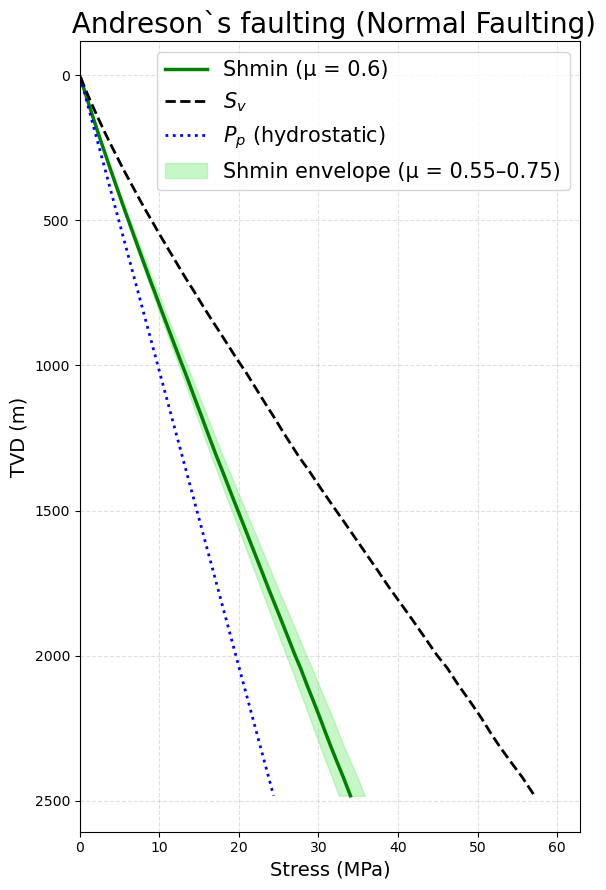

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# PARAMETERS (friction method)
# =============================

mu_avg = 0.65
mu_vals = np.linspace(0.55, 0.75, 50)

# Hydrostatic pore pressure
Pp = 0.00981 * depth
Sv = pressure_mpa



# ----- Average Shmin
K_avg = (np.sqrt(mu_avg**2 + 1) + mu_avg)**2
Sh_avg = Pp + (Sv - Pp) / K_avg

# ----- Envelope
K_low = (np.sqrt(mu_vals.min()**2 + 1) + mu_vals.min())**2
K_high = (np.sqrt(mu_vals.max()**2 + 1) + mu_vals.max())**2

Sh_low = Pp + (Sv - Pp) / K_high
Sh_high = Pp + (Sv - Pp) / K_low

# =============================
# PLOT
# =============================

plt.style.use("default")

fig, ax = plt.subplots(figsize=(6, 9))

# Envelope
ax.fill_betweenx(depth, Sh_low, Sh_high,
                 color="lightgreen", alpha=0.5,
                 label="Shmin envelope (μ = 0.55–0.75)")

# Lines
ax.plot(Sh_avg, depth, color="green", linewidth=2.5,
        label="Shmin (μ = 0.6)")

ax.plot(Sv, depth, color="black", linestyle="--", linewidth=2,
        label="$S_v$")

ax.plot(Pp, depth, color="blue", linestyle=":", linewidth=2,
        label="$P_p$ (hydrostatic)")

# Axis formatting
ax.invert_yaxis()
ax.set_xlim(0, np.max(Sv)*1.1)

ax.set_xlabel("Stress (MPa)", fontsize=14)
ax.set_ylabel("TVD (m)", fontsize=14)
ax.set_title(" Andreson`s faulting (Normal Faulting)", fontsize=20)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# Legend
ax.legend(loc="upper right", frameon=True, fontsize=15)

plt.tight_layout()

print(np.max(Sh_avg))
plt.savefig("Shmin_frictionalnew.png", dpi=300, bbox_inches="tight", transparent=True)


plt.show()


ValueError: x and y must have same first dimension, but have shapes (1,) and (53,)

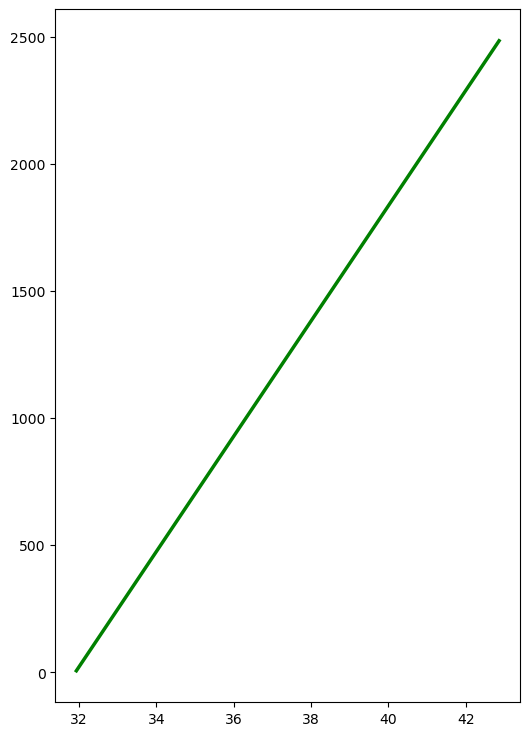

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# ESR PARAMETER
# =============================

ESR = 0.55

# Hydrostatic pore pressure
Pp = 0.00981 * depth

# Shmin from ESR equation
Sh_avg = Pp + ESR * (Sv - Pp)

# =============================
# PLOT
# =============================

plt.style.use("default")

fig, ax = plt.subplots(figsize=(6, 9))

# Shmin line
ax.plot(Sh_avg, depth, color="green", linewidth=2.5,
        label="Shmin (ESR = 0.55)")

# Sv
ax.plot(Sv, depth, color="black", linestyle="--", linewidth=2,
        label="$S_v$")

# Pp
ax.plot(Pp, depth, color="blue", linestyle=":", linewidth=2,
        label="$P_p$ (hydrostatic)")

# Axis formatting
ax.invert_yaxis()
ax.set_xlim(0, np.max(Sv)*1.1)

ax.set_xlabel("Stress (MPa)", fontsize=14)
ax.set_ylabel("TVD (m)", fontsize=14)
ax.set_title("Minimum Horizontal Stress (ESR Method)", fontsize=20)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# Legend
ax.legend(loc="upper right", frameon=True, fontsize=14)

plt.tight_layout()

print(np.max(Sh_avg))


plt.savefig("Shmin_ESR.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()


52.237409624839316


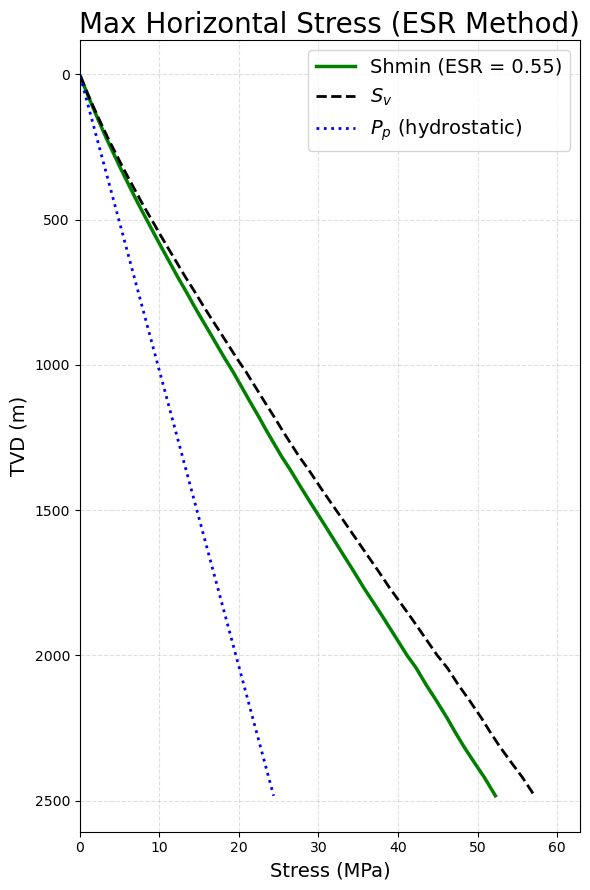

In [181]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# ESR PARAMETER
# =============================

ESR = 0.85

# Hydrostatic pore pressure
Pp = 0.00981 * depth

# Shmin from ESR equation
SH_avg = Pp + ESR * (Sv - Pp)

# =============================
# PLOT
# =============================

plt.style.use("default")

fig, ax = plt.subplots(figsize=(6, 9))

# Shmin line
ax.plot(SH_avg, depth, color="green", linewidth=2.5,
        label="Shmin (ESR = 0.55)")

# Sv
ax.plot(Sv, depth, color="black", linestyle="--", linewidth=2,
        label="$S_v$")

# Pp
ax.plot(Pp, depth, color="blue", linestyle=":", linewidth=2,
        label="$P_p$ (hydrostatic)")

# Axis formatting
ax.invert_yaxis()
ax.set_xlim(0, np.max(Sv)*1.1)

ax.set_xlabel("Stress (MPa)", fontsize=14)
ax.set_ylabel("TVD (m)", fontsize=14)
ax.set_title("Max Horizontal Stress (ESR Method)", fontsize=20)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# Legend
ax.legend(loc="upper right", frameon=True, fontsize=14)

plt.tight_layout()

print(np.max(SH_avg))


plt.savefig("SHmax_ESR.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()


In [176]:
import pandas as pd
import numpy as np

df = pd.read_excel("DepthInfo.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Convert to numeric
TVD_survey = pd.to_numeric(df["TVD"], errors="coerce").to_numpy()
MD_survey = pd.to_numeric(df["MD"], errors="coerce").to_numpy()

# Remove NaNs
mask = np.isfinite(TVD_survey) & np.isfinite(MD_survey)
TVD_survey = TVD_survey[mask]
MD_survey = MD_survey[mask]

# Convert TVD_53 to float just in case
TVD_53 = np.array(TVD_import, dtype=float)

# Interpolate
MD_53 = np.interp(TVD_53, TVD_survey, MD_survey)

print(MD_53)
print(len(MD_53))


[   6.27272727   42.31363636   74.35909091  110.4136364   150.4681818
  186.5045455   222.54826459  250.5918182   286.6327273   322.6645455
  358.7054545   394.7418182   438.7781818   478.8190909   514.85799335
  554.8972727   598.96325473  651.23895636  699.70119579  748.49268093
  797.66551858  847.3915771   893.82564019  936.98350034  994.74109332
 1045.73679712 1115.3826366  1181.13711519 1255.580348   1323.52159969
 1385.64722811 1447.87549867 1510.82460851 1600.564314   1680.06727762
 1771.33302521 1844.86516873 1923.83521309 2002.38970542 2086.20319962
 2152.70385581 2225.22091353 2326.75461566 2413.27092213 2477.25995048
 2559.79876695 2645.40038948 2736.54166546 2812.46327308 2881.82025185
 2931.         2931.         2931.        ]
53


42.39980805702897


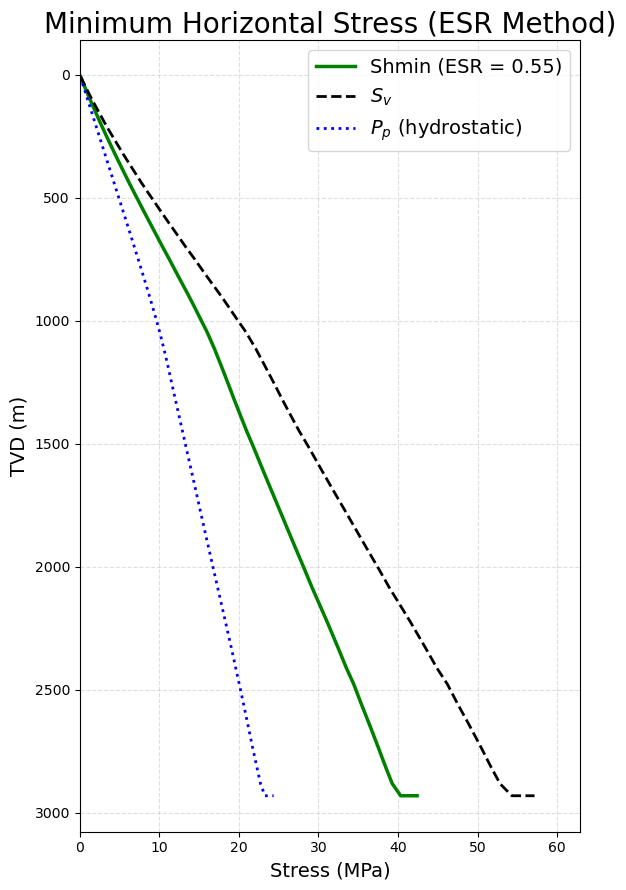

In [179]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# ESR PARAMETER
# =============================

ESR = 0.55

# Hydrostatic pore pressure
Pp = 0.00981 * depth

Sv = pressure_mpa


# Shmin from ESR equation
Sh_avg = Pp + ESR * (Sv - Pp)

# =============================
# PLOT
# =============================

plt.style.use("default")

fig, ax = plt.subplots(figsize=(6, 9))

# Shmin line
ax.plot(Sh_avg, MD_53, color="green", linewidth=2.5,
        label="Shmin (ESR = 0.55)")

# Sv
ax.plot(Sv, MD_53, color="black", linestyle="--", linewidth=2,
        label="$S_v$")

# Pp
ax.plot(Pp, MD_53, color="blue", linestyle=":", linewidth=2,
        label="$P_p$ (hydrostatic)")

# Axis formatting
ax.invert_yaxis()
ax.set_xlim(0, np.max(Sv)*1.1)

ax.set_xlabel("Stress (MPa)", fontsize=14)
ax.set_ylabel("TVD (m)", fontsize=14)
ax.set_title("Minimum Horizontal Stress (ESR Method)", fontsize=20)

# Grid
ax.grid(True, linestyle="--", alpha=0.4)

# Legend
ax.legend(loc="upper right", frameon=True, fontsize=14)

plt.tight_layout()

print(np.max(Sh_avg))


plt.savefig("Shmin_ESR_MD.png", dpi=300, bbox_inches="tight", transparent=True)

plt.show()


In [8]:
# Breakouts can be observed on 6-arm caliper data from well NLW-GT03-S1. 
#These features are limited to the top of the Lower Holland Marl Formation. 
#The rest of the well displays minor or no breakouts.


import numpy as np

# =============================
# INPUT PARAMETERS
# =============================

# Rock properties
UCS = 16.0                 # MPa
mu = 0.48                  # internal friction coefficient
sigma_T = 0.0              # tensile strength (MPa)

# Stresses
sigma_h = 15.0             # minimum horizontal stress (MPa)
Pp = 9.0                   # pore pressure (MPa)
Pm = 11.28                 # mud pressure (MPa)

# Breakout geometry
breakout_width_deg = 60.0  # total breakout width (deg)
theta_bo = breakout_width_deg / 2.0  # half-angle

# =============================
# CALCULATIONS
# =============================

# Friction angle
phi = np.arctan(mu)
sin_phi = np.sin(phi)

# Mohr-Coulomb parameter
q = (1 + sin_phi) / (1 - sin_phi)

# Breakout geometry terms
cos_theta = np.cos(np.deg2rad(theta_bo))
term1 = 1 - 2 * cos_theta
term2 = 1 + 2 * cos_theta

# Mechanical contribution
mechanical_term = UCS - term1 * sigma_h + sigma_T

# Pressure contribution
pressure_term = (q + 1) * Pm - (q - 1) * Pp

# Final SHmax
sigma_H = (mechanical_term + pressure_term) / term2

# =============================
# OUTPUT
# =============================

print("===== Breakout Stress Calculation =====")
print(f"Friction angle (deg): {np.rad2deg(phi):.2f}")
print(f"q parameter: {q:.3f}")
print(f"cos(theta_bo): {cos_theta:.3f}")
print("---------------------------------------")
print(f"Mechanical term: {mechanical_term:.2f} MPa")
print(f"Pressure term: {pressure_term:.2f} MPa")
print("---------------------------------------")
print(f"SHmax = {sigma_H:.2f} MPa")


===== Breakout Stress Calculation =====
Friction angle (deg): 25.64
q parameter: 2.526
cos(theta_bo): 0.866
---------------------------------------
Mechanical term: 26.98 MPa
Pressure term: 26.04 MPa
---------------------------------------
SHmax = 19.41 MPa


In [15]:
import numpy as np

def compute_sigma_H(sigma_v, sigma_h, pore_pressure, alpha,
                    young_modulus_GPa, strain_micro, poisson_ratio):
    """
    Computes maximum horizontal stress using:

    σ_H = ν(σ_v + σ_h − 2αp_p) + αp_p + Eε_H
    """

    # Convert units
    E = young_modulus_GPa * 1000      # GPa → MPa
    strain = strain_micro * 1e-6      # microstrain → strain

    # Compute terms
    bracket_term = sigma_v + sigma_h - 2 * alpha * pore_pressure
    strain_term = E * strain

    sigma_H = (
        poisson_ratio * bracket_term
        + alpha * pore_pressure
        + strain_term
    )

    return sigma_H


# ---- Example values ----
sigma_v = 57.5           # MPa
sigma_h = 42         # MPa
pore_pressure = 24     # MPa
alpha = 1
E_GPa = 32
poisson_ratio = 0.27

# Example 1: 750 microstrain
sigma_H_750 = compute_sigma_H(
    sigma_v, sigma_h, pore_pressure, alpha,
    E_GPa, 750, poisson_ratio
)

# Example 2: 350 microstrain
sigma_H_350 = compute_sigma_H(
    sigma_v, sigma_h, pore_pressure, alpha,
    E_GPa, 450, poisson_ratio
)

print(f"σ_H (750 µε) = {sigma_H_750:.3f} MPa")
print(f"σ_H (350 µε) = {sigma_H_350:.3f} MPa")


σ_H (750 µε) = 61.905 MPa
σ_H (350 µε) = 52.305 MPa


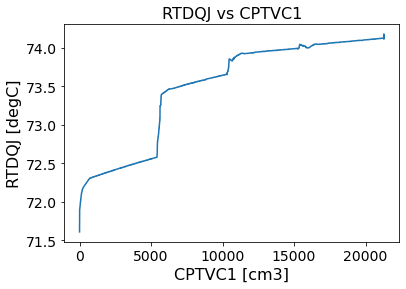

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_name = "TU_DELFT_GT02_MICROFRAC_converted_simple.txt"  # same folder as script

df = pd.read_csv(file_name, sep="\t", engine="python")

temp_col = "RTDQJ [degC]"
vol_col  = "CPTVC1 [cm3]"

# Replace missing value code with NaN (use numpy.nan, not pd.NA)
df = df.replace(-999.250, np.nan)

# Convert columns to plain floats
df[temp_col] = pd.to_numeric(df[temp_col], errors="coerce")
df[vol_col]  = pd.to_numeric(df[vol_col],  errors="coerce")

# Drop rows with missing x or y
df = df.dropna(subset=[temp_col, vol_col])

# Convert to numpy arrays (this avoids the multidim indexing issue)
x = df[vol_col].to_numpy(dtype=float)
y = df[temp_col].to_numpy(dtype=float)

plt.figure()
plt.plot(x, y)
plt.xlabel("CPTVC1 [cm3]")
plt.ylabel("RTDQJ [degC]")
plt.title("RTDQJ vs CPTVC1")
plt.show()

In [30]:
import numpy as np

def thermal_stress(alpha, E_GPa, nu, Tm_C, Tf_C, return_MPa=True):
    """
    Compute thermal stress using:
        sigma_T = alpha * E * (Tm - Tf) / (1 - nu)

    Parameters
    ----------
    alpha : float
        Linear thermal expansion coefficient [1/K].
        Example from your plot: 1.48e-5 to 1.51e-5 1/K.
    E_GPa : float
        Young's modulus [GPa].
    nu : float
        Poisson's ratio [-].
    Tm_C : float
        Rock/borehole wall temperature [°C].
    Tf_C : float
        Fluid temperature [°C].
    return_MPa : bool
        If True, returns stress in MPa; otherwise in Pa.

    Returns
    -------
    sigma : float
        Thermal stress (magnitude) in MPa (default) or Pa.
    """
    dT = Tm_C - Tf_C  # temperature difference; °C == K for differences
    E_Pa = E_GPa * 1e9
    sigma_Pa = alpha * E_Pa * dT / (1.0 - nu)
    return sigma_Pa / 1e6 if return_MPa else sigma_Pa


if __name__ == "__main__":
    # --- Inputs (edit as needed) ---
    Tf = 75.0          # fluid temperature [°C]
    Tm = 80         # rock/borehole wall temperature [°C]
    E  = 28.0          # Young's modulus [GPa]
    nu = 0.27          # Poisson's ratio [-]

    # Thermal expansion from your figure (a) and (b)
    alpha_a = 1.48e-5  # [1/K]
    alpha_b = 1.51e-5  # [1/K]
    alpha_mean = 0.5 * (alpha_a + alpha_b)

    # --- Calculations ---
    sig_a = thermal_stress(alpha_a, E, nu, Tm, Tf)      # MPa
    sig_b = thermal_stress(alpha_b, E, nu, Tm, Tf)      # MPa
    sig_m = thermal_stress(alpha_mean, E, nu, Tm, Tf)   # MPa

    # --- Output ---
    dT = Tm - Tf
    print("Thermal stress calculation")
    print("--------------------------")
    print(f"Tm = {Tm:.2f} °C, Tf = {Tf:.2f} °C, ΔT = {dT:.2f} K")
    print(f"E  = {E:.2f} GPa, ν = {nu:.3f}")
    print()
    print(f"α (panel a) = {alpha_a:.3e} 1/K  -> σ_T = {sig_a:.2f} MPa")
    print(f"α (panel b) = {alpha_b:.3e} 1/K  -> σ_T = {sig_b:.2f} MPa")
    print(f"α (mean)    = {alpha_mean:.3e} 1/K  -> σ_T = {sig_m:.2f} MPa")

Thermal stress calculation
--------------------------
Tm = 80.00 °C, Tf = 75.00 °C, ΔT = 5.00 K
E  = 28.00 GPa, ν = 0.270

α (panel a) = 1.480e-05 1/K  -> σ_T = 2.84 MPa
α (panel b) = 1.510e-05 1/K  -> σ_T = 2.90 MPa
α (mean)    = 1.495e-05 1/K  -> σ_T = 2.87 MPa


In [35]:
import numpy as np

def sigma_H_max(
    sigma_h_min_MPa: float,
    Pb_MPa: float,
    Pp_MPa: float,
    sigma_T_MPa: float = 0.0,
    T0_MPa: float = 0.0,
    k: float = 1.0,
) -> float:
    """
    Compute maximum horizontal stress from:
        σ_H = 3σ_h - p_b - p_p + σ_T + k T0

    Parameters
    ----------
    sigma_h_min_MPa : float
        Minimum horizontal stress σ_h [MPa].
    Pb_MPa : float
        Breakdown pressure p_b [MPa].
    Pp_MPa : float
        Pore pressure p_p [MPa].
    sigma_T_MPa : float, optional
        Thermal stress term σ_T [MPa]. Default 0.
    T0_MPa : float, optional
        Tensile strength T0 [MPa]. Default 0.
    k : float, optional
        Tensile strength scaling factor k [-]. Default 1.

    Returns
    -------
    float
        Maximum horizontal stress σ_H [MPa].
    """
    return 3.0 * sigma_h_min_MPa - Pb_MPa - Pp_MPa + sigma_T_MPa + k * T0_MPa


if __name__ == "__main__":
    # ---- Inputs (edit as needed) ----
    sigma_h = 38.0      # MPa (minimum horizontal stress)
    T0 = 1.0            # MPa (tensile strength)
    Pb = 43.5           # MPa (breakdown pressure)
    Pp = 23           # MPa (pore pressure)

    # If you want to include your previously computed thermal stress:
    sigma_T = 0       # MPa (set to 0.0 to ignore thermal effect)

    # Tensile scaling factor (often assumed 1 if not otherwise defined)
    k = 1.0

    # ---- Calculation ----
    sigma_H = sigma_H_max(
        sigma_h_min_MPa=sigma_h,
        Pb_MPa=Pb,
        Pp_MPa=Pp,
        sigma_T_MPa=sigma_T,
        T0_MPa=T0,
        k=k
    )

    # ---- Output ----
    print("Maximum horizontal stress estimate")
    print("---------------------------------")
    print(f"σ_h (min) = {sigma_h:.2f} MPa")
    print(f"p_b       = {Pb:.2f} MPa")
    print(f"p_p       = {Pp:.2f} MPa")
    print(f"σ_T       = {sigma_T:.2f} MPa")
    print(f"T0        = {T0:.2f} MPa")
    print(f"k         = {k:.2f}")
    print()
    print(f"σ_H (max) = {sigma_H:.2f} MPa")

Maximum horizontal stress estimate
---------------------------------
σ_h (min) = 38.00 MPa
p_b       = 43.50 MPa
p_p       = 23.00 MPa
σ_T       = 0.00 MPa
T0        = 1.00 MPa
k         = 1.00

σ_H (max) = 48.50 MPa


In [42]:
def eta_permeable(alpha_biot: float, nu: float) -> float:
    """
    Compute eta for permeable rocks:
        η = α * (1 - 2ν) / (2(1 - ν))

    Parameters
    ----------
    alpha_biot : float
        Biot coefficient α [-], typically ~0.6–1.0 for sedimentary rocks.
    nu : float
        Poisson's ratio ν [-], typically ~0.20–0.30 for sandstone.

    Returns
    -------
    float
        η [-]
    """
    if not (0.0 <= alpha_biot <= 1.5):
        raise ValueError("alpha_biot looks unrealistic; expected ~0 to ~1 (occasionally slightly >1 in some models).")
    if not (0.0 < nu < 0.5):
        raise ValueError("Poisson's ratio nu must be between 0 and 0.5 (exclusive).")

    return alpha_biot * (1.0 - 2.0 * nu) / (2.0 * (1.0 - nu))


def sigma_H_permeable(
    sigma_h_MPa: float,
    pb_MPa: float,
    pp_MPa: float,
    T0_MPa: float,
    alpha_biot: float,
    nu: float,
) -> float:
    """
    Maximum horizontal stress for permeable rocks:
        σ_H = 3σ_h - 2(1 - η) p_b - 2η p_p + T0
    where:
        η = α * (1 - 2ν) / (2(1 - ν))

    All stresses/pressures in MPa.

    Returns
    -------
    float
        σ_H [MPa]
    """
    eta = eta_permeable(alpha_biot, nu)
    return 3.0 * sigma_h_MPa - 2.0 * (1.0 - eta) * pb_MPa - 2.0 * eta * pp_MPa + T0_MPa


if __name__ == "__main__":
    # ---- Inputs (edit as needed) ----
    sigma_h = 38.0     # MPa  (minimum horizontal stress)
    pb = 43.5          # MPa  (breakdown pressure)
    pp = 22.0          # MPa  (pore pressure)
    T0 = 1.0           # MPa  (tensile strength)

    # Rock parameters for permeable-rock correction
    alpha_biot = 1   # [-]  (Biot coefficient; choose based on rock)
    nu = 0.27          # [-]  (Poisson's ratio)

    # ---- Compute ----
    eta = eta_permeable(alpha_biot, nu)
    sigma_H = sigma_H_permeable(sigma_h, pb, pp, T0, alpha_biot, nu)

    # ---- Output ----
    print("Permeable-rock maximum horizontal stress")
    print("---------------------------------------")
    print(f"σ_h  = {sigma_h:.2f} MPa")
    print(f"p_b  = {pb:.2f} MPa")
    print(f"p_p  = {pp:.2f} MPa")
    print(f"T0   = {T0:.2f} MPa")
    print(f"α    = {alpha_biot:.3f}  (Biot coefficient)")
    print(f"ν    = {nu:.3f}  (Poisson's ratio)")
    print()
    print(f"η    = {eta:.4f}")
    print(f"σ_H  = {sigma_H:.2f} MPa")

Permeable-rock maximum horizontal stress
---------------------------------------
σ_h  = 38.00 MPa
p_b  = 43.50 MPa
p_p  = 22.00 MPa
T0   = 1.00 MPa
α    = 1.000  (Biot coefficient)
ν    = 0.270  (Poisson's ratio)

η    = 0.3151
σ_H  = 41.55 MPa


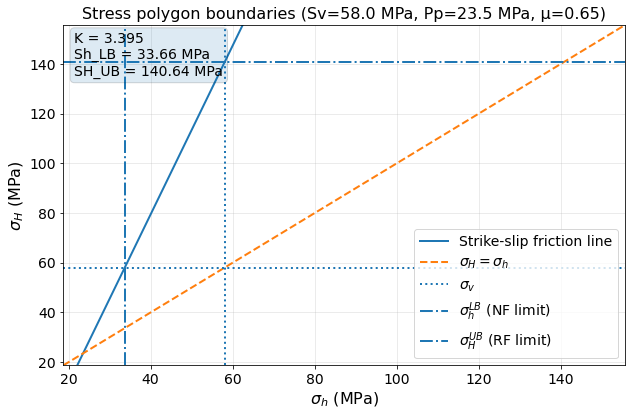

In [51]:
import numpy as np
import matplotlib.pyplot as plt


def friction_factor_K(mu: float) -> float:
    """
    Frictional faulting factor (a.k.a. 'stress ratio' at failure):

        (σ1' / σ3') = K = [ sqrt(mu^2 + 1) + mu ]^2

    where σ' = effective stress = total stress - pore pressure.
    """
    return (np.sqrt(mu**2 + 1.0) + mu) ** 2


def stress_polygon_bounds(Sv_MPa: float, Pp_MPa: float, mu: float = 0.6):
    """
    Returns key stress-polygon boundary quantities for a given Sv and Pp:

    - Sh_LB: lower bound on minimum horizontal stress from normal-faulting limit
            (Sv - Pp)/(Sh_LB - Pp) = K  ->  Sh_LB = Pp + (Sv - Pp)/K

    - SH_UB: upper bound on maximum horizontal stress from thrust-faulting limit
            (SH_UB - Pp)/(Sv - Pp) = K  ->  SH_UB = Pp + K*(Sv - Pp)

    - Strike-slip friction line: (SH - Pp)/(Sh - Pp) = K  ->  SH = Pp + K*(Sh - Pp)
    """
    K = friction_factor_K(mu)
    Sv_eff = Sv_MPa - Pp_MPa
    if Sv_eff <= 0:
        raise ValueError("Sv must be greater than Pp to form a meaningful polygon in effective stress.")

    Sh_LB = Pp_MPa + Sv_eff / K
    SH_UB = Pp_MPa + K * Sv_eff
    return K, Sh_LB, SH_UB


def plot_stress_polygon_boundaries(Sv_MPa: float, Pp_MPa: float, mu: float = 0.6):
    K, Sh_LB, SH_UB = stress_polygon_bounds(Sv_MPa, Pp_MPa, mu)

    # Sh range for plotting
    x_min = max(0.0, Sh_LB - 15)
    x_max = max(SH_UB, Sv_MPa) + 15
    sh = np.linspace(x_min, x_max, 500)

    # Boundary lines
    SH_ss = Pp_MPa + K * (sh - Pp_MPa)       # strike-slip friction line
    SH_diag = sh                              # SH = Sh (ordering line)

    # Create figure
    plt.figure(figsize=(9, 6))

    # Plot the main boundary lines
    plt.plot(sh, SH_ss, linewidth=2, label="Strike-slip friction line")
    plt.plot(sh, SH_diag, linewidth=2, linestyle="--", label=r"$\sigma_H=\sigma_h$")

    # Sv reference lines
    plt.axvline(Sv_MPa, linestyle=":", linewidth=2, label=r"$\sigma_v$")
    plt.axhline(Sv_MPa, linestyle=":", linewidth=2)

    # Bounds from NF and RF limits
    plt.axvline(Sh_LB, linestyle="-.", linewidth=2, label=r"$\sigma_h^{LB}$ (NF limit)")
    plt.axhline(SH_UB, linestyle="-.", linewidth=2, label=r"$\sigma_H^{UB}$ (RF limit)")

    # Helpful annotation
    plt.title(f"Stress polygon boundaries (Sv={Sv_MPa:.1f} MPa, Pp={Pp_MPa:.1f} MPa, μ={mu:.2f})")
    plt.xlabel(r"$\sigma_h$ (MPa)")
    plt.ylabel(r"$\sigma_H$ (MPa)")
    plt.grid(True, alpha=0.3)

    # Plot limits (keep it readable)
    plt.xlim(x_min, x_max)
    plt.ylim(max(0.0, Sh_LB - 15), max(SH_UB, Sv_MPa) + 15)

    # Print computed values on the plot
    text = (
        f"K = {K:.3f}\n"
        f"Sh_LB = {Sh_LB:.2f} MPa\n"
        f"SH_UB = {SH_UB:.2f} MPa"
    )
    plt.text(0.02, 0.98, text, transform=plt.gca().transAxes,
             va="top", ha="left",
             bbox=dict(boxstyle="round", alpha=0.15))

    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # ---- Your inputs ----
    Sv = 58.0     # MPa
    Pp = 23.5     # MPa
    mu = 0.65      # coefficient of friction (common range ~0.6–1.0)

    plot_stress_polygon_boundaries(Sv_MPa=Sv, Pp_MPa=Pp, mu=mu)

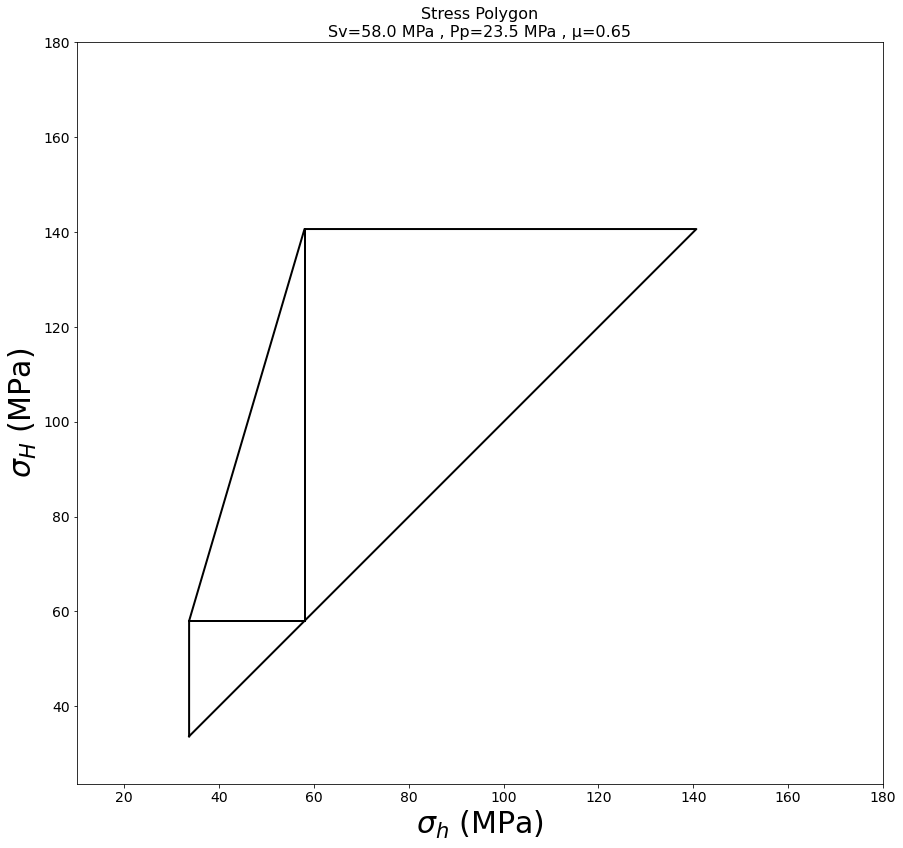

K     = 3.395
Sh_LB = 33.66 MPa
SH_UB = 140.64 MPa


In [75]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
Sv = 58.0     # MPa
Pp = 23.5     # MPa
mu = 0.65

# -----------------------------
# Friction factor
# K = [sqrt(mu^2+1) + mu]^2
# -----------------------------
K = (np.sqrt(mu**2 + 1.0) + mu) ** 2

Sv_eff = Sv - Pp
if Sv_eff <= 0:
    raise ValueError("Sv must be > Pp.")

# Bounds
Sh_LB = Pp + Sv_eff / K
SH_UB = Pp + K * Sv_eff

# -----------------------------
# Polygon vertices (match the textbook-style polygon)
# -----------------------------
A = (Sh_LB, Sh_LB)     # lower-left
B = (Sh_LB, Sv)        # up to Sv at Sh_LB
C = (Sv, SH_UB)        # up to SH_UB at Sv
D = (SH_UB, SH_UB)     # right along top
E = (Sv, Sv)           # down to (Sv,Sv) on diagonal
# close back to A

poly_x = [A[0], B[0], C[0], D[0], E[0], A[0]]
poly_y = [A[1], B[1], C[1], D[1], E[1], A[1]]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(20,12))
# Outer polygon
plt.plot(poly_x, poly_y, color="black", linewidth=2)

# ---- Internal "keep these lines" segments (finite only) ----
# Horizontal: y = Sv from x = Sh_LB to x = Sv
plt.plot([Sh_LB, Sv], [Sv, Sv], color="black", linewidth=2)

# Vertical: x = Sv from y = Sv to y = SH_UB
plt.plot([Sv, Sv], [Sv, SH_UB], color="black", linewidth=2)

# Labels / formatting
plt.xlabel(r"$\sigma_h$ (MPa)", fontsize=30)
plt.ylabel(r"$\sigma_H$ (MPa)",fontsize=30)
plt.title(f"Stress Polygon\nSv={Sv:.1f} MPa , Pp={Pp:.1f} MPa , μ={mu:.2f}")

# Nice limits
pad = 10
plt.xlim(10, 180)
plt.ylim(max(0, Sh_LB - pad), 180)

plt.gca().set_aspect("equal", adjustable="box")
plt.grid(False)
plt.tight_layout()
plt.show()

# Optional: print key values
print(f"K     = {K:.3f}")
print(f"Sh_LB = {Sh_LB:.2f} MPa")
print(f"SH_UB = {SH_UB:.2f} MPa")

fig.tight_layout()
fig.savefig("stress_polygon.png", dpi=300, bbox_inches="tight")
plt.show()


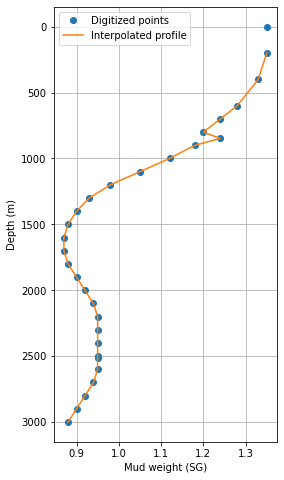

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Digitized mud weight data (SG)
# -----------------------------------
z_mud = np.array([
    0, 200, 400, 600, 700, 800, 848,
    900, 1000, 1100, 1200, 1300, 1400,
    1500, 1600, 1700, 1800, 1900, 2000,
    2100, 2200, 2300, 2400, 2500, 2511,
    2600, 2700, 2800, 2900, 3000
])

# Mud weight (SG) – digitized from plot
mw = np.array([
    1.35, 1.35, 1.33, 1.28, 1.24, 1.20, 1.24,
    1.18, 1.12, 1.05, 0.98, 0.93, 0.90,
    0.88, 0.87, 0.87, 0.88, 0.90, 0.92,
    0.94, 0.95, 0.95, 0.95, 0.95, 0.95,
    0.95, 0.94, 0.92, 0.90, 0.88
])

# -----------------------------------
# 2. Query depths (define your own)
# -----------------------------------
z_query = np.linspace(200, 3000, 1000)

# -----------------------------------
# 3. Linear interpolation
# -----------------------------------
mw_interp = np.interp(z_query, z_mud, mw)

# -----------------------------------
# 4. Plot (sanity check)
# -----------------------------------
plt.figure(figsize=(4, 8))
plt.plot(mw, z_mud, 'o', label='Digitized points')
plt.plot(mw_interp, z_query, '-', label='Interpolated profile')
plt.gca().invert_yaxis()
plt.xlabel('Mud weight (SG)')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid(True)
plt.show()


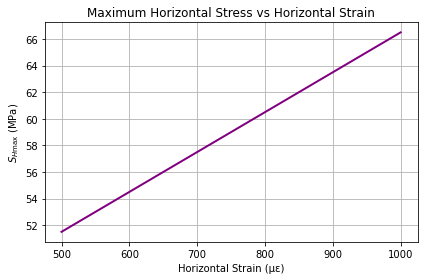

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Fixed parameters
# -----------------------------
E = 30000.0          # MPa
nu = 0.25
alpha = 1.0

Sv = 59.0            # MPa
Sh = 35.0            # MPa
Pp = 26.0            # MPa

# -----------------------------
# Horizontal strain range
# -----------------------------
eps_micro = np.linspace(500, 1000, 100)      # microstrain
eps = eps_micro * 1e-6                        # strain

# -----------------------------
# SHmax calculation
# -----------------------------
SHmax = (
    nu * (Sv + Sh - 2 * alpha * Pp)
    + alpha * Pp
    + E * eps
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 4))

plt.plot(eps_micro, SHmax, lw=2, color="purple")

plt.xlabel("Horizontal Strain (µε)")
plt.ylabel(r"$S_{H\max}$ (MPa)")
plt.title("Maximum Horizontal Stress vs Horizontal Strain")

plt.grid(True)
plt.tight_layout()
plt.show()


In [151]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from ipywidgets import interact

In [152]:
@interact(SHmax=(7000,10000,20),Shmin=(6000,7000,20),Pw=(4000,8000,20)) # Widget variables 
def plotter(SHmax=8000,Shmin=6000,Pw=4000):
    # define linear space for theta
    theta = np.linspace(1,360,90) # [degrees] angle from SHmax
    a = 0.5 # wellbore radius [ft]
    r = 0.5 # distance from wellbore
    # define a few more variables
    Ts = 200 # [psi] rock tensile strength
    UCS = 9000 # [psi] rock UCS
    q = 3 # friction parameter (1+sin(phi))/(1-sin(phi))
    Pp = 4000 # [psi] pore pressure
    sigHmax = SHmax - Pp
    sighmin = Shmin - Pp
    # calculate hoop and radial stress  
    sigma_rr = (Pw-Pp)*(a**2/r**2) + (sigHmax+sighmin)/2*(1-a**2/r**2) + (sigHmax-sighmin)/2*(1-4*a**2/r**2+3*a**4/r**4)*np.cos(2*theta*3.1415/180)    
    sigma_tt = -(Pw-Pp)*(a**2/r**2) + (sigHmax+sighmin)/2*(1+a**2/r**2) - (sigHmax-sighmin)/2*(1+3*a**4/r**4)*np.cos(2*theta*3.1415/180)
    #check failure
    #Ts
    index = 0
    TensFrac = np.zeros(len(theta))
    for x in sigma_tt:
        if x < (-Ts):
            TensFrac[index] = 1
        index = index + 1
    #shear
    ShearFrac = np.zeros(len(theta))
    sigma_1avail = UCS + q*sigma_rr
    index2 = 0
    for x in sigma_tt:
        if x > sigma_1avail[index2]:
            ShearFrac[index2] = 1
        index2 = index2 + 1
    ### plotting
    plt.subplot(211) # plot pore pressure, vertical stress and seafloor
    plt.plot(theta,sigma_rr, 'b-', label = "sigma_rr")
    plt.plot(theta,sigma_tt, 'r-', label = "sigma_tt")
    # plotting options
    plt.xlabel('theta [deegres]')
    plt.ylabel('Stress [psi] (Pp=4000psi)')
    plt.xlim(0,360)
    plt.ylim(-5000,15000)
    #plt.gca().invert_yaxis()
    plt.legend()
    plt.subplot(212) # check failure criterion
    plt.plot(theta,TensFrac, 'b+', label = "Tensile Fractures")
    plt.plot(theta,ShearFrac, 'rx', label = "Shear Failure")
    # plotting options
    plt.xlabel('theta [deegres]')
    plt.ylabel('Failure [1:YES, 0;NO]')
    plt.xlim(0,360)
    plt.legend()
    ### debugging
    #print(theta)
    #print(sigma_rr)
    #print(TensFrac)

interactive(children=(IntSlider(value=8000, description='SHmax', max=10000, min=7000, step=20), IntSlider(valu…

In [146]:
import numpy as np

# -------------------------
# Table 5: UCS tests
# -------------------------

Vp_ucs = np.array([
    3073, 2634, 2109, 2230,
    3032, 2936, 2610, 2667, 2922, 3544,
    4267, 4568, 4099, 4372
])

Vs_ucs = np.array([
    1960, 1911, 1343, 1547,
    2187, 1932, 1720, 1757, 1799, 2269,
    2651, 2820, 2708, 2664
])

rho_ucs = np.array([
    2.13, 2.38, 2.17, 2.25,
    2.03, 2.12, 2.19, 2.09,
    2.59, 2.56, 2.64, 2.59
])


In [132]:
# -------------------------
# Table 6: Triaxial tests
# -------------------------

Vp_trx = np.array([
    2742, 2409, 1486,
    2693, 2912, 2970, 2888, 4411,
    3998, 4561, 2598, 3599, 4411
])

Vs_trx = np.array([
    1890, 1668, 1173,
    1754, 2010, 2180, 1971, 3006,
    2575, 2747, 1666, 2195, 2802
])

rho_trx = np.array([
    2.11, 2.11, 2.22,
    2.09, 2.13, 2.34, 2.08, 2.61,
    2.59, 2.61, 2.58, 2.57, 2.63
])


In [147]:
Vp_all = np.concatenate([Vp_ucs, Vp_trx])
Vs_all = np.concatenate([Vs_ucs, Vs_trx])
rho_all = np.concatenate([rho_ucs, rho_trx])


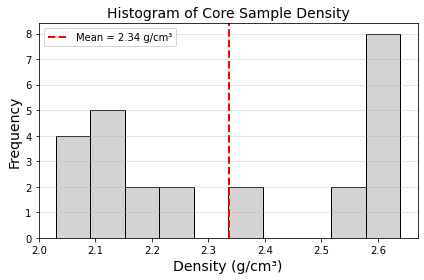

Average density = 2.34 g/cm³


In [148]:
import numpy as np
import matplotlib.pyplot as plt

# Merge densities (if not already done)
rho_all = np.concatenate([rho_ucs, rho_trx])

# Compute average
rho_mean = np.mean(rho_all)

# Plot histogram
plt.figure(figsize=(6, 4))
plt.hist(
    rho_all,
    bins=10,
    edgecolor="black",
    color="lightgray"
)

# Plot mean line
plt.axvline(
    rho_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {rho_mean:.2f} g/cm³"
)

plt.xlabel("Density (g/cm³)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Histogram of Core Sample Density", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

# Print average
print(f"Average density = {rho_mean:.2f} g/cm³")
